Professional financial theme applied to all visualizations
Sample of Banking Dataset:
  Client ID             Name  Age  Location ID Joined Bank   Banking Contact  \
0  IND81288    Raymond Mills   24        34324  06-05-2019    Anthony Torres   
1  IND65833    Julia Spencer   23        42205  10-12-2001  Jonathan Hawkins   
2  IND47499   Stephen Murray   27         7314  25-01-2010     Anthony Berry   
3  IND72498   Virginia Garza   40        34594  28-03-2019        Steve Diaz   
4  IND60181  Melissa Sanders   46        41269  20-07-2012        Shawn Long   

  Nationality            Occupation Fee Structure Loyalty Classification  ...  \
0    American  Safety Technician IV          High                   Jade  ...   
1     African   Software Consultant          High                   Jade  ...   
2    European    Help Desk Operator          High                   Gold  ...   
3    American          Geologist II           Mid                 Silver  ...   
4    American   Assistant Pr

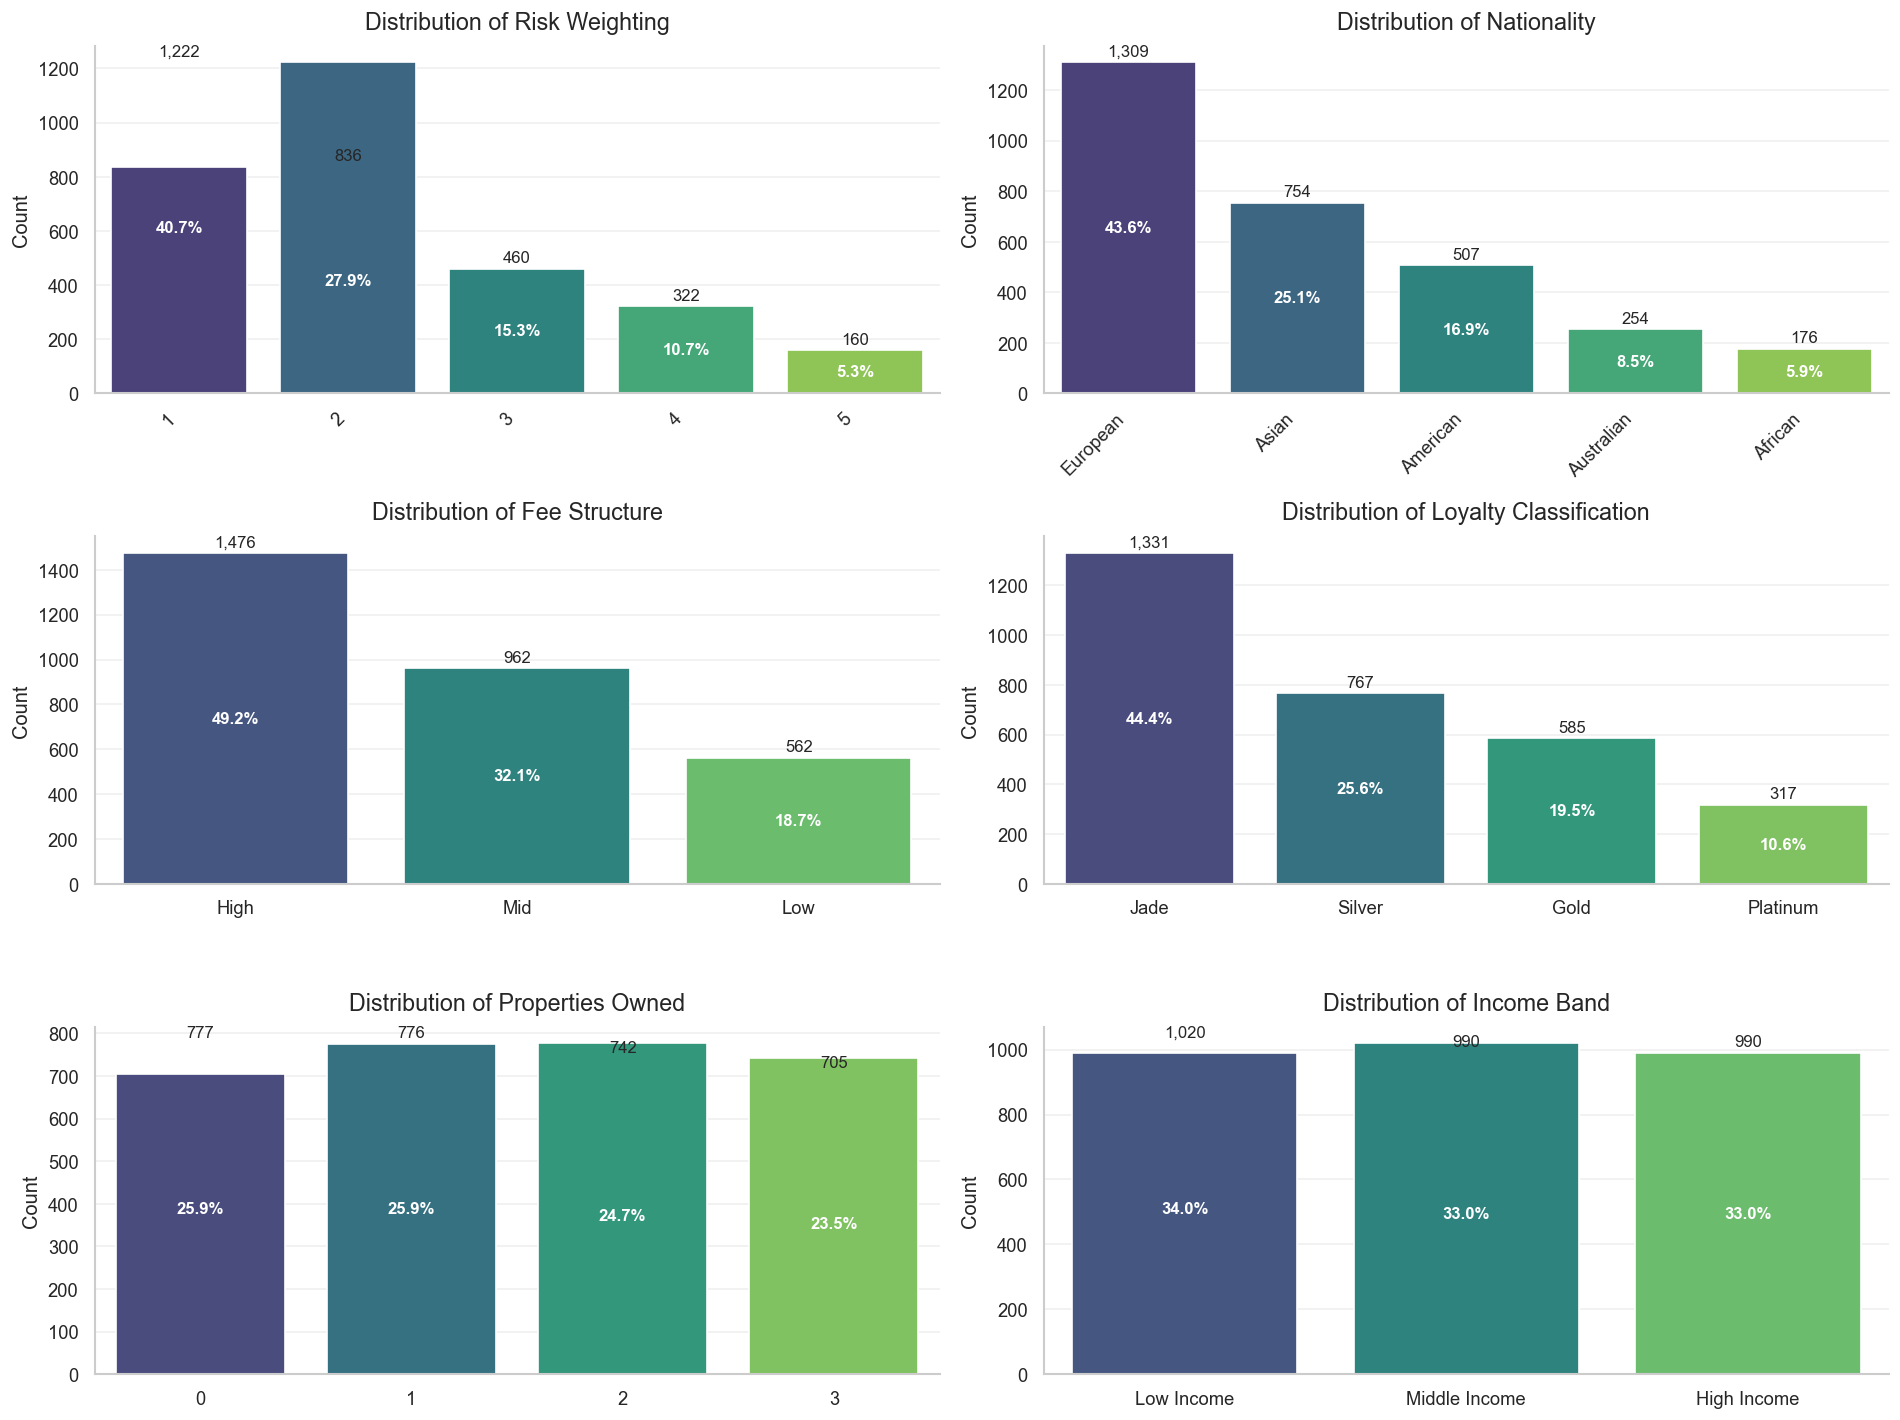

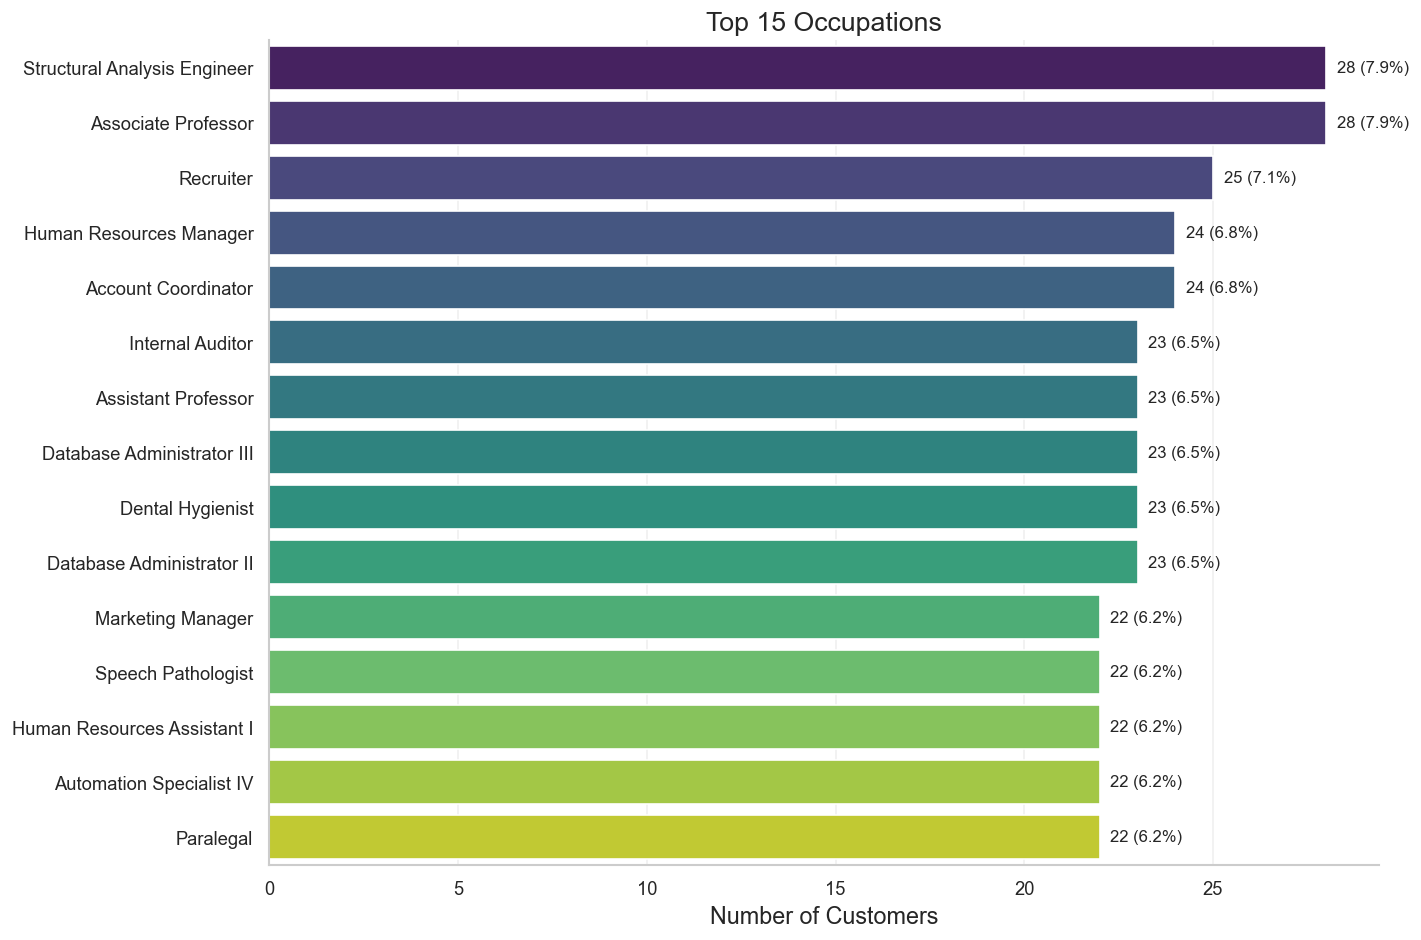


Descriptive Statistics for Numerical Columns:
                           count           mean            std       min  \
Age                       3000.0      51.039667      19.854760     17.00   
Location ID               3000.0   21563.323000   12462.273017     12.00   
Estimated Income          3000.0  171305.034263  111935.808209  15919.48   
Superannuation Savings    3000.0   25531.599673   16259.950770   1482.03   
Amount of Credit Cards    3000.0       1.463667       0.676387      1.00   
Credit Card Balance       3000.0    3176.206943    2497.094709      1.17   
Bank Loans                3000.0  591386.155487  457557.036334      0.00   
Bank Deposits             3000.0  671560.193923  645716.856875      0.00   
Checking Accounts         3000.0  321092.949127  282079.553893      0.00   
Saving Accounts           3000.0  232908.353483  230007.777498      0.00   
Foreign Currency Account  3000.0   29883.529993   23109.924010     45.00   
Business Lending          3000.0  866759.

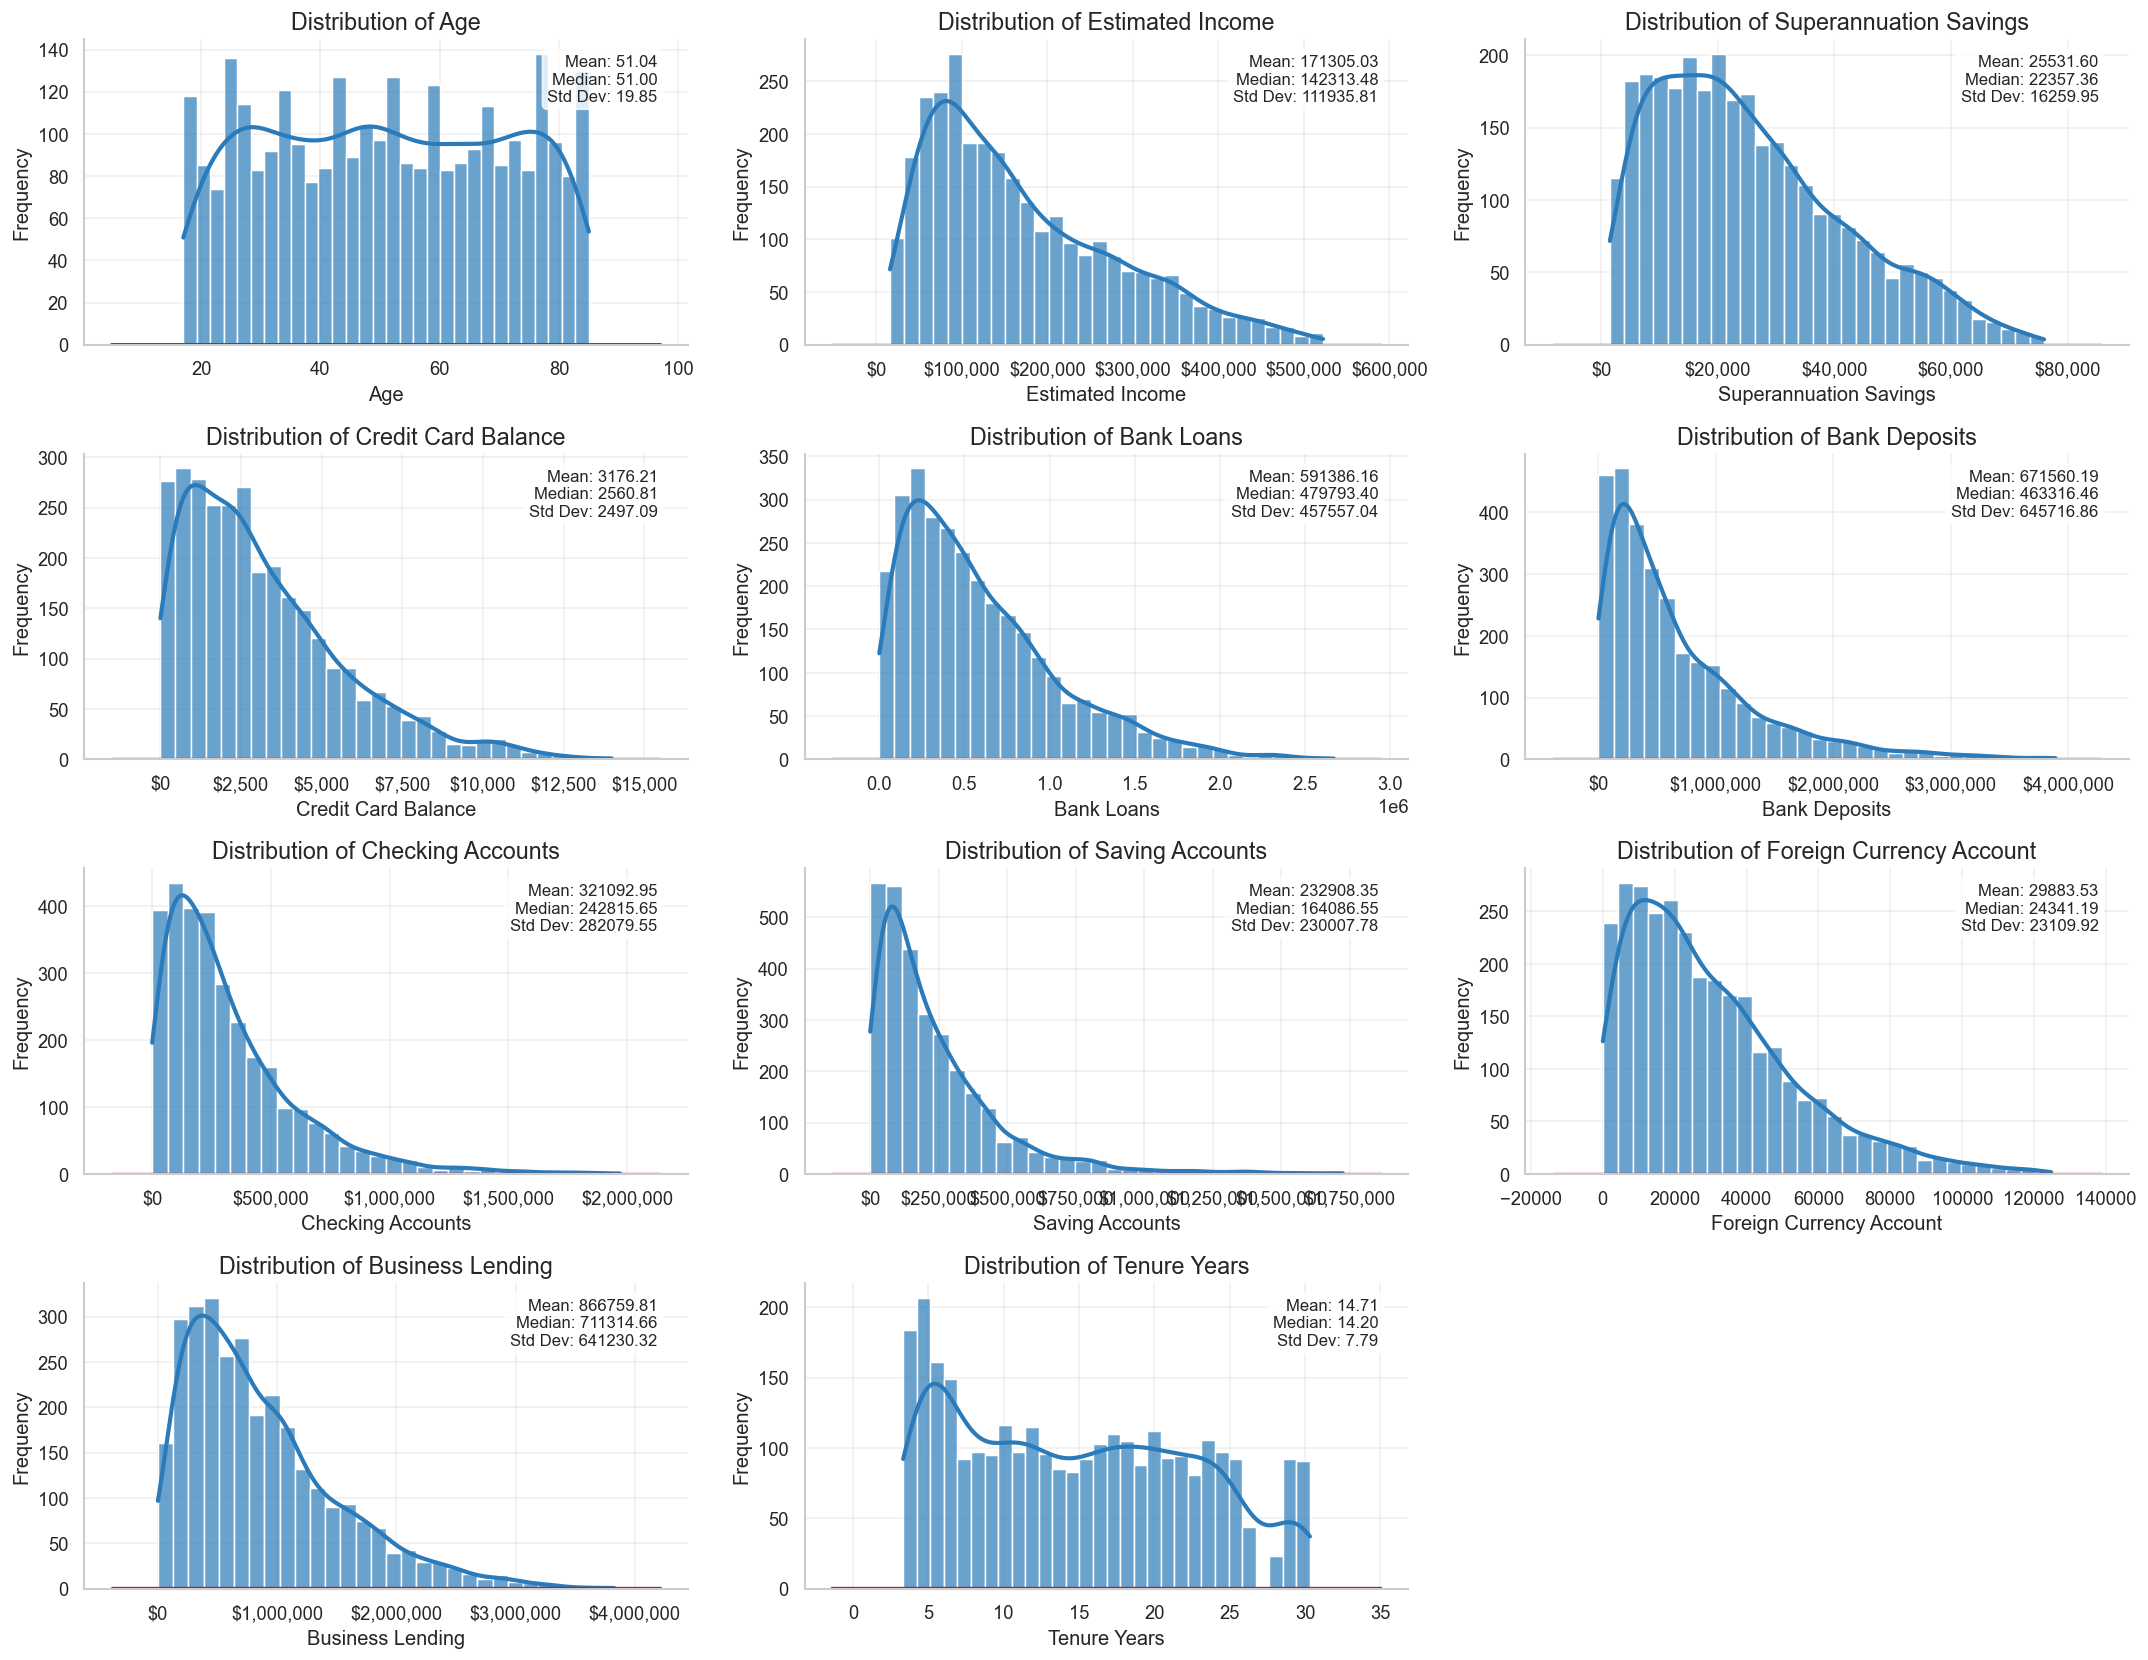

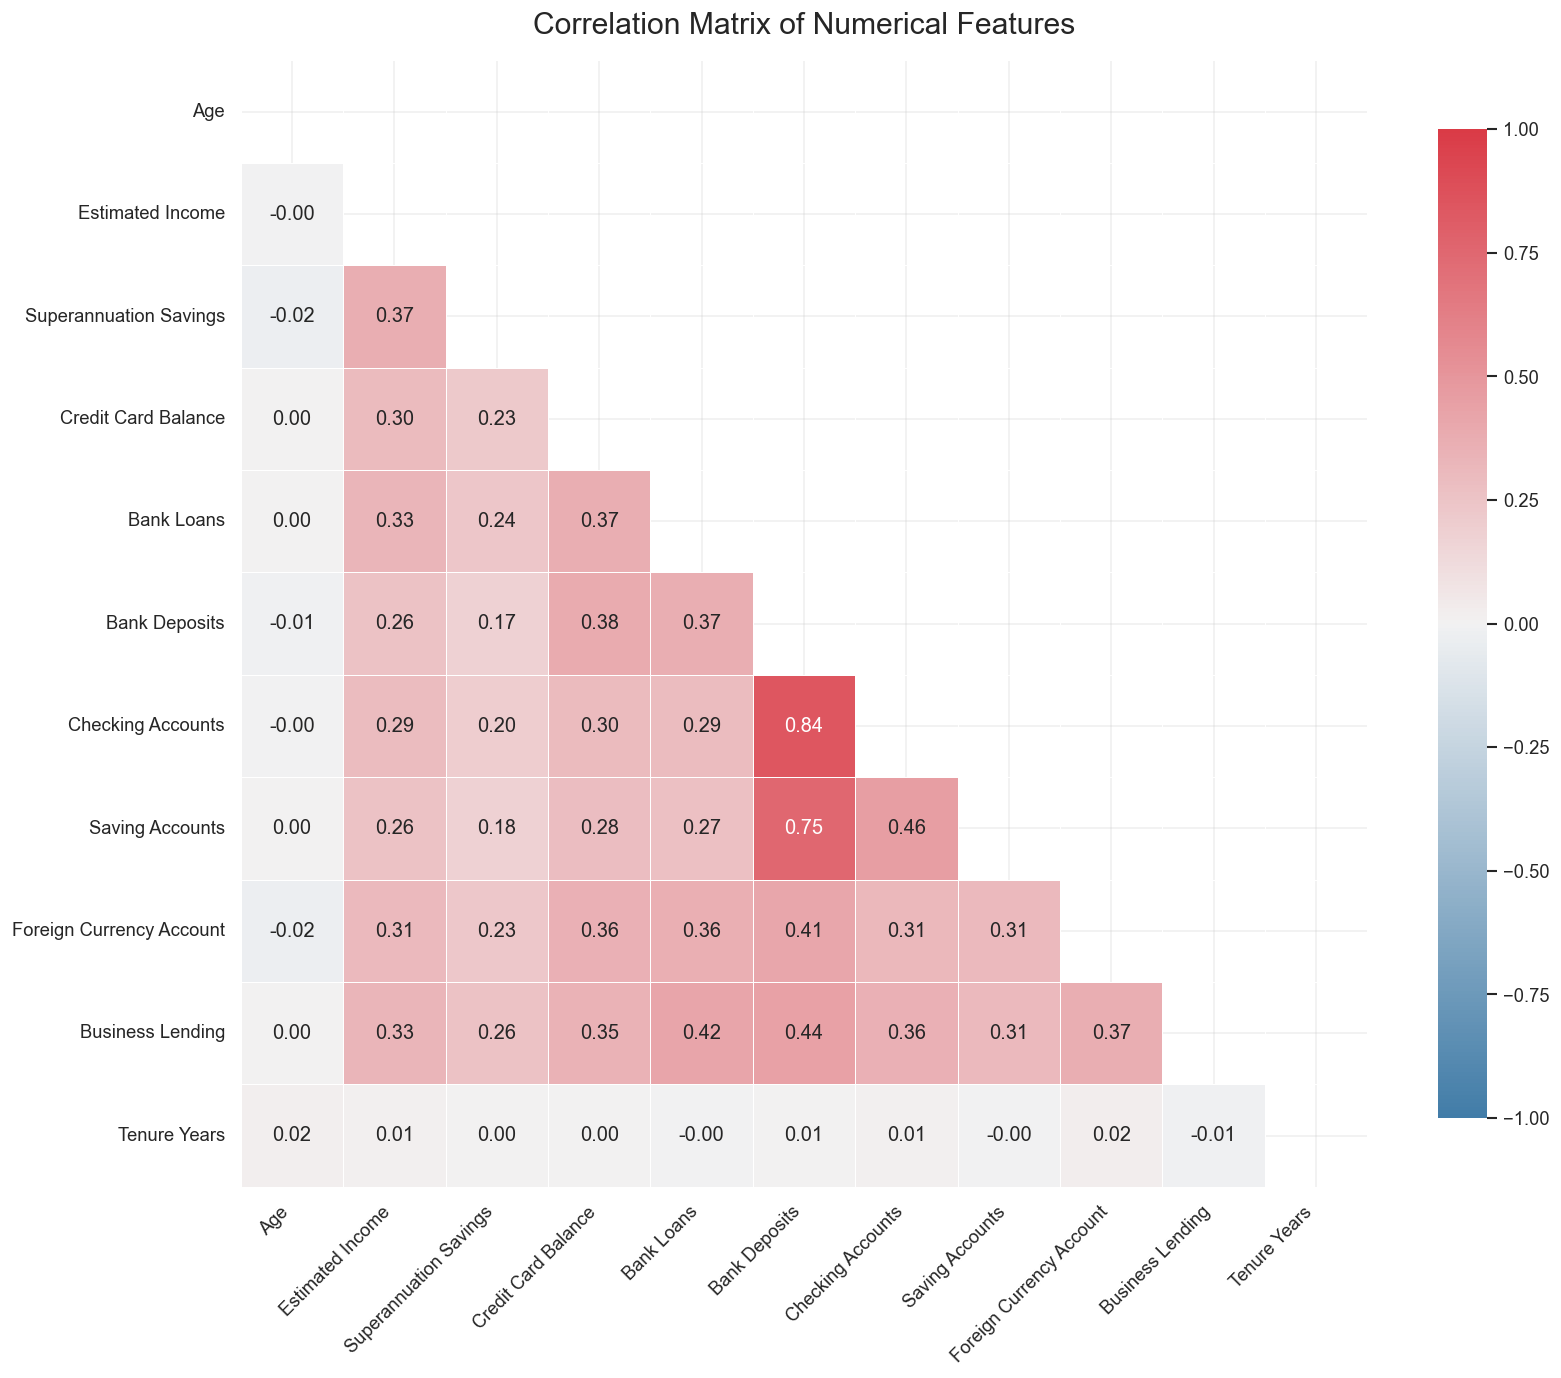

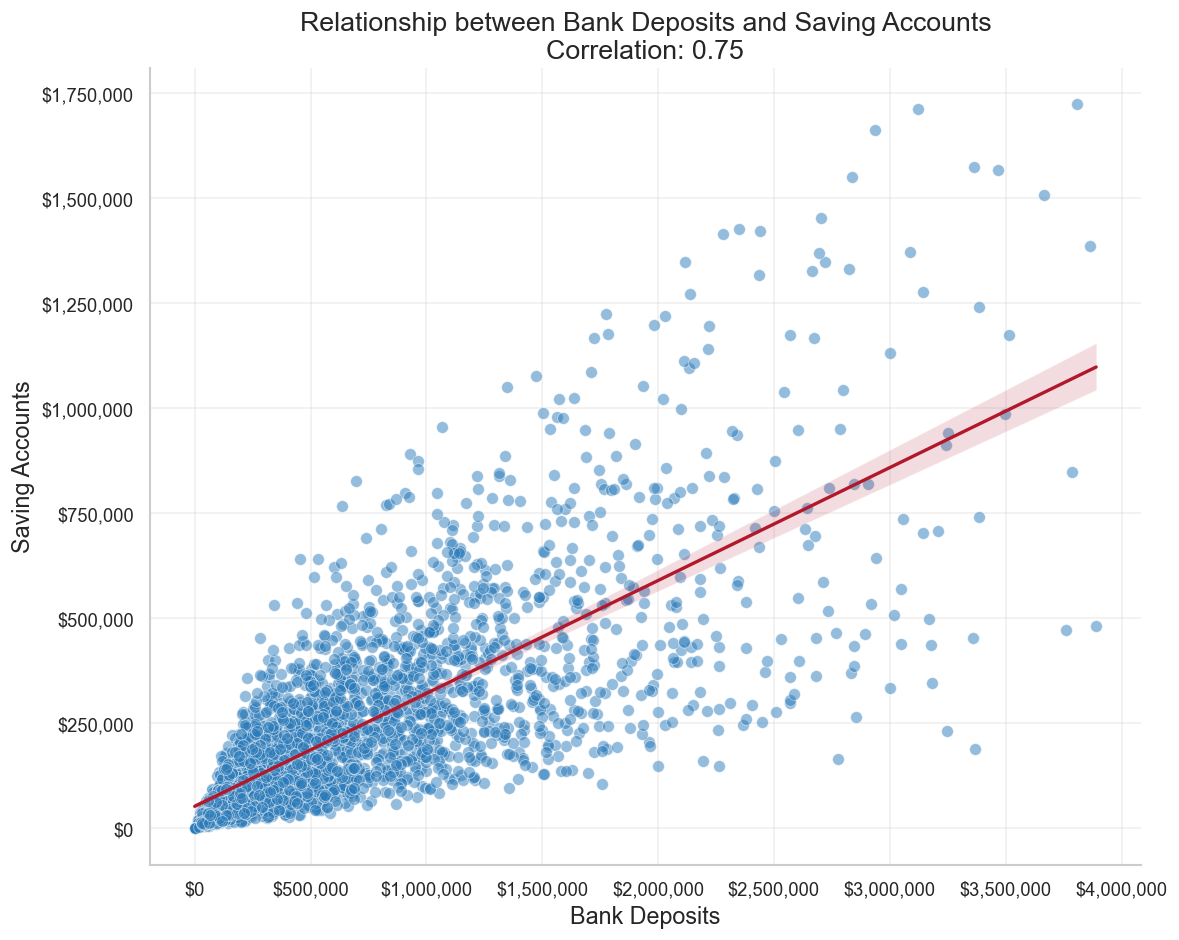

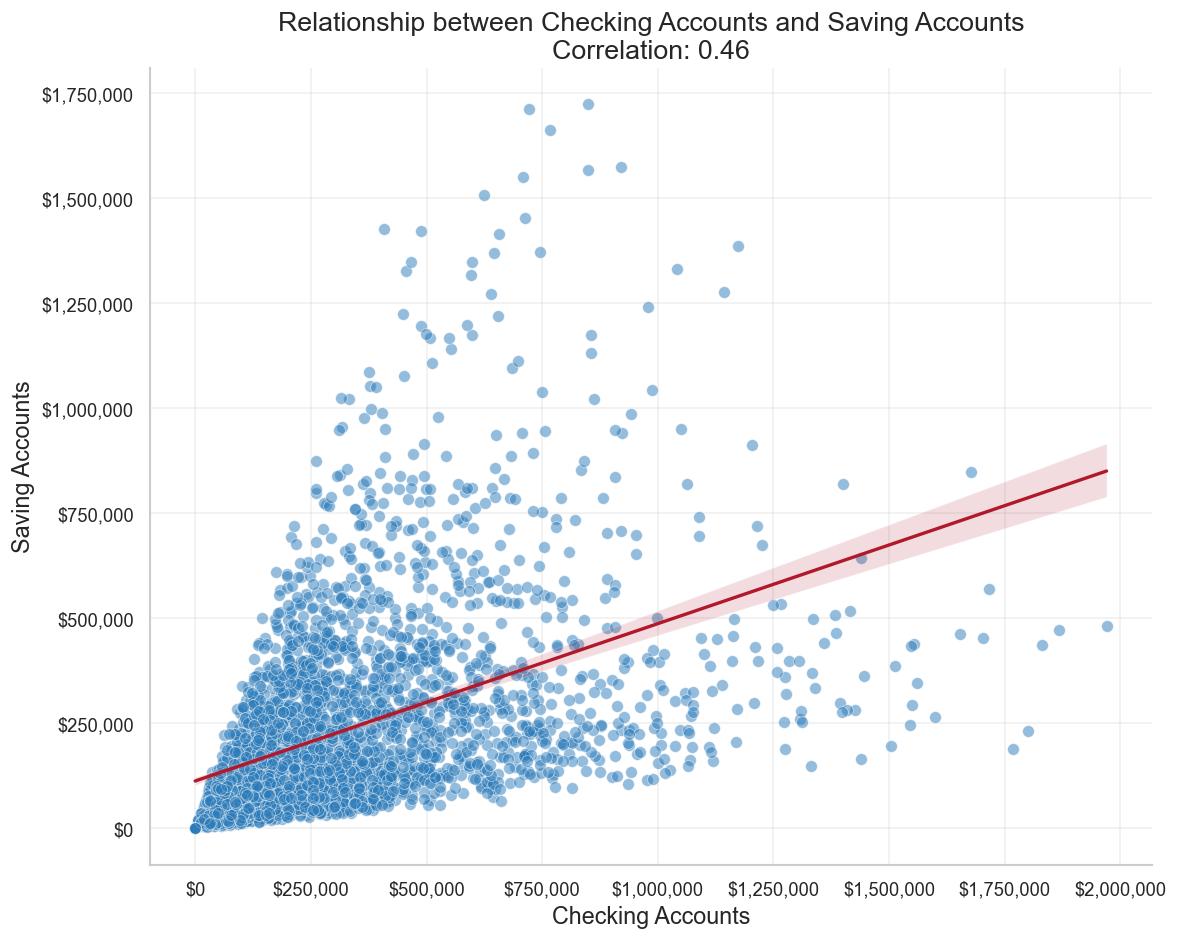

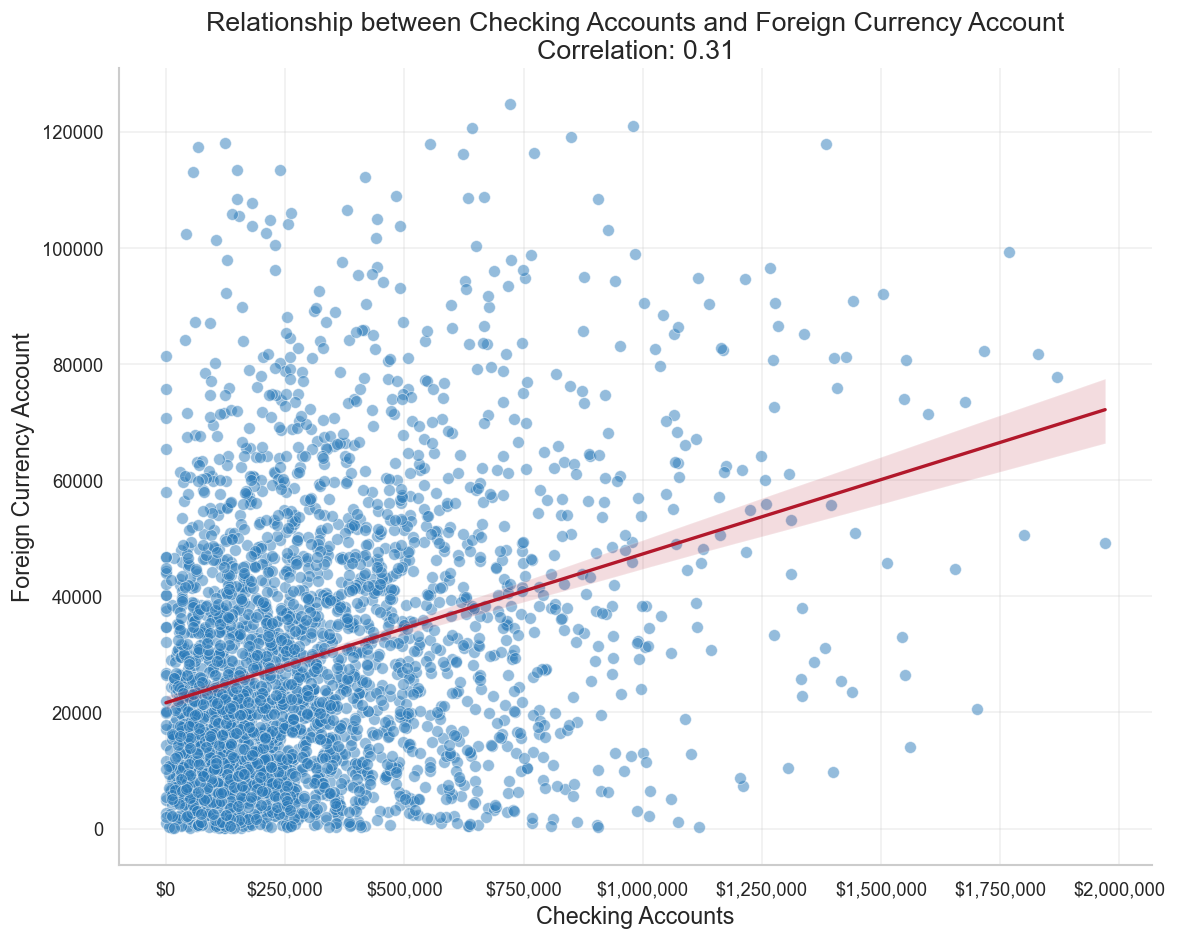

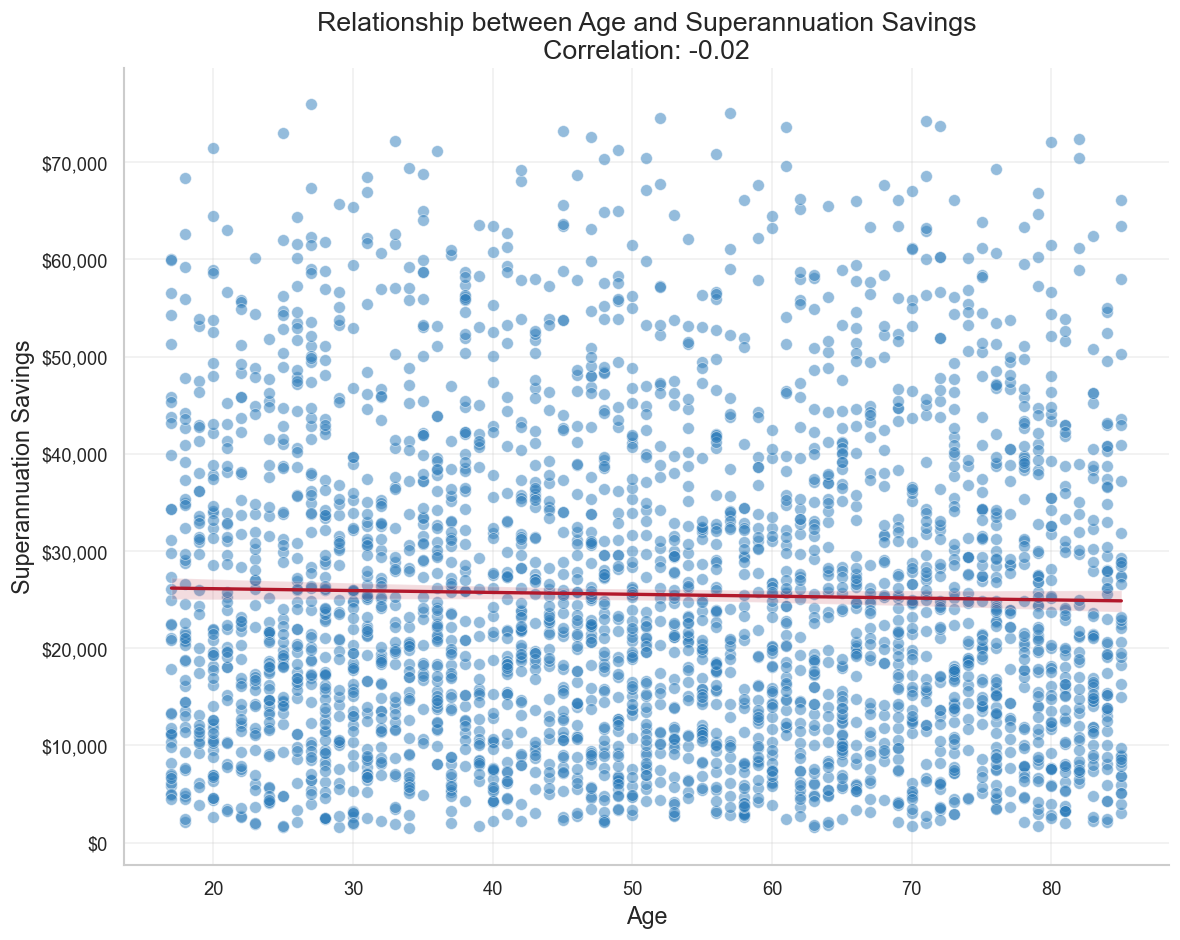

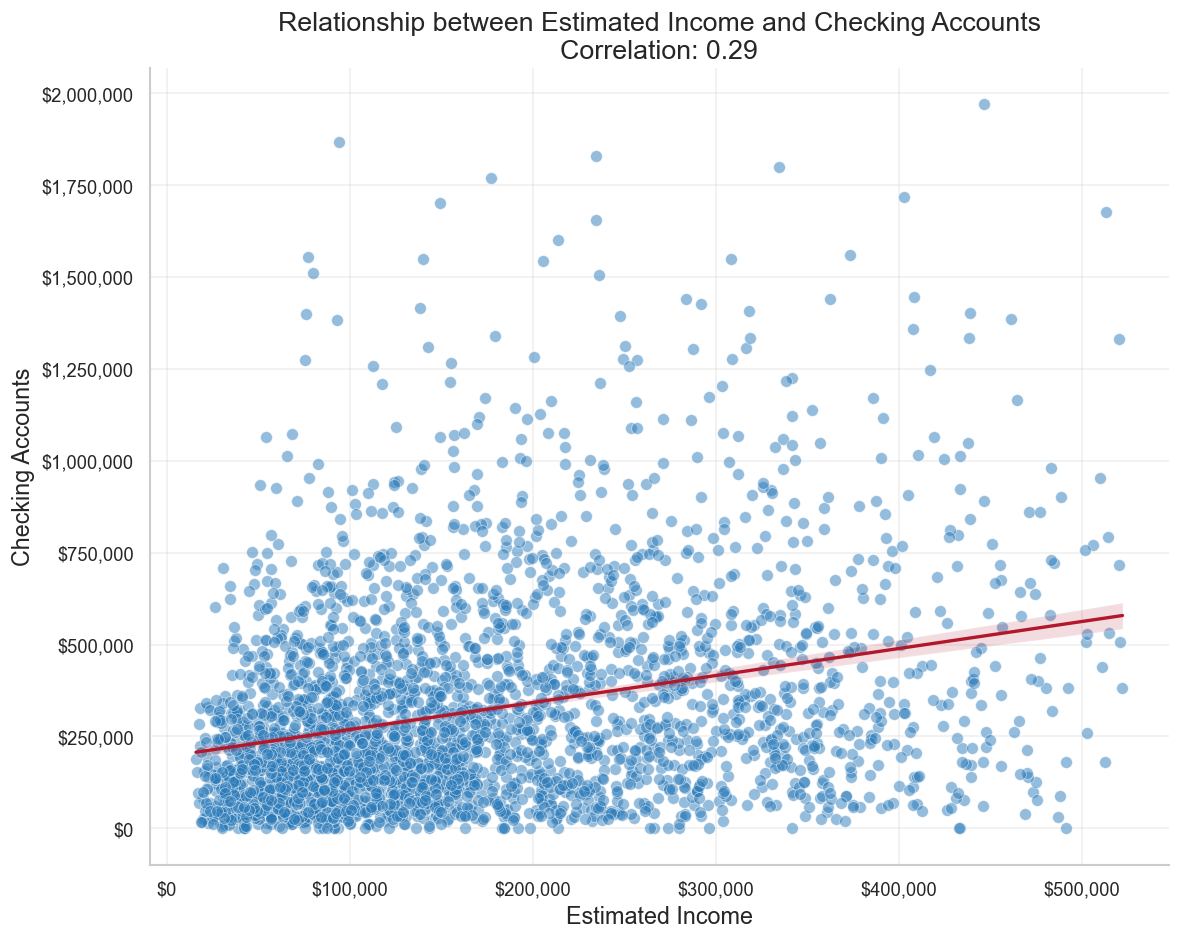

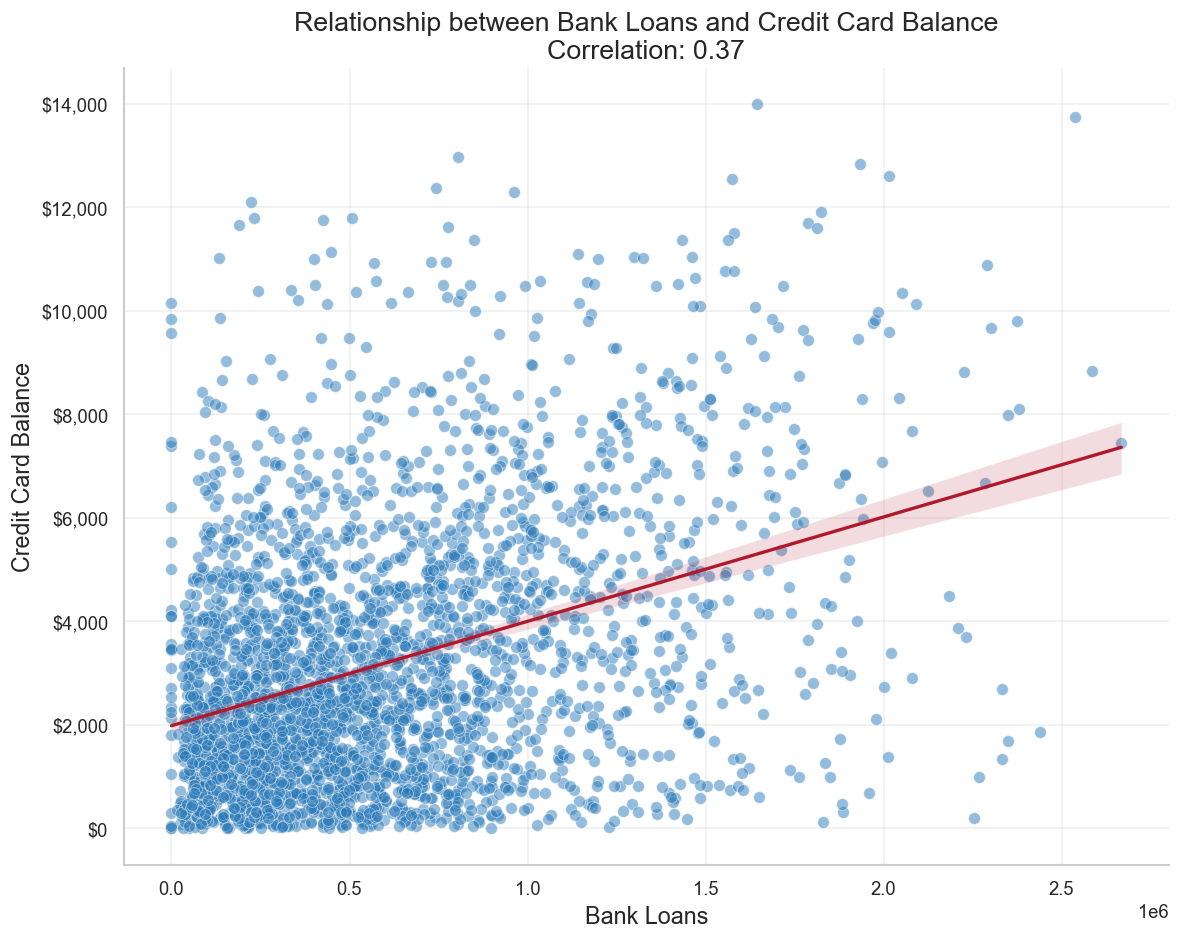

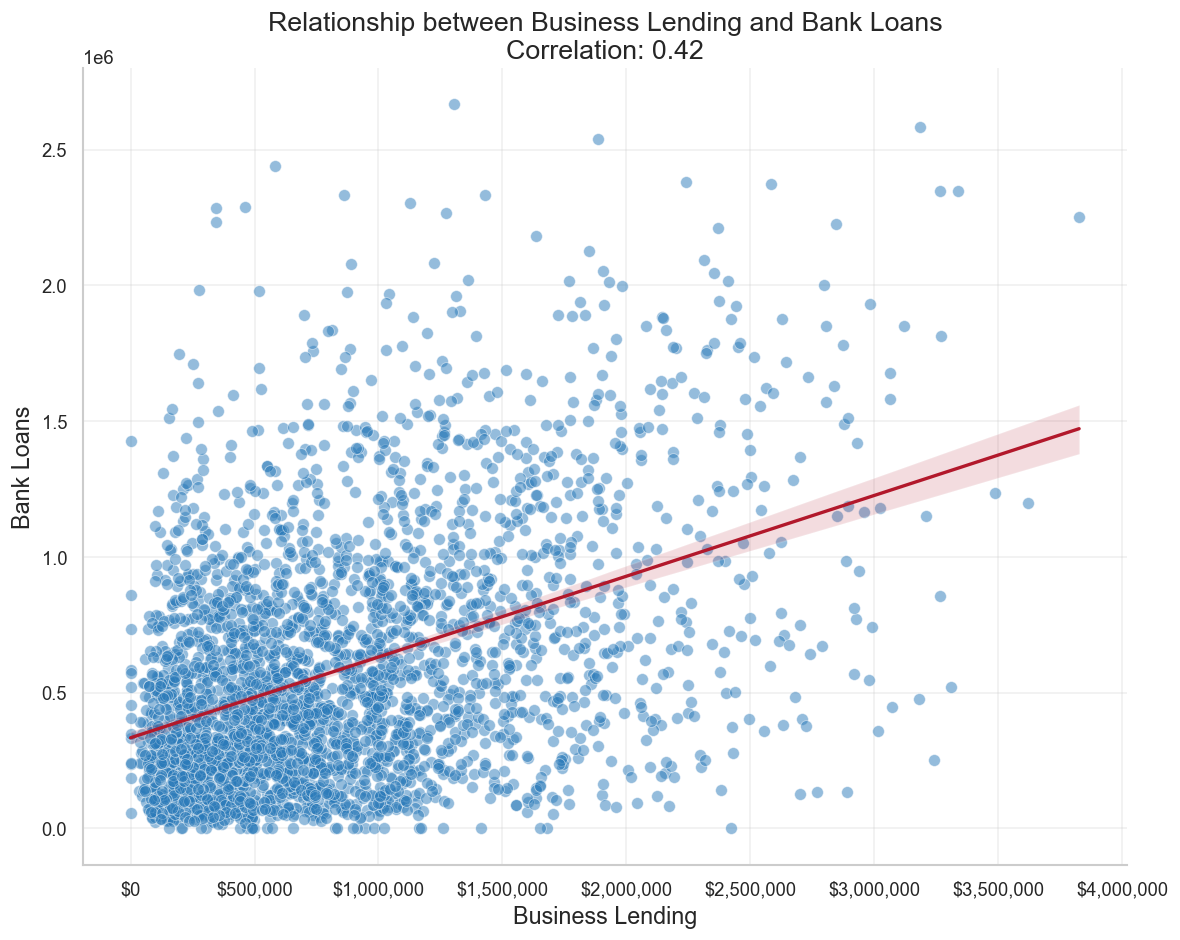

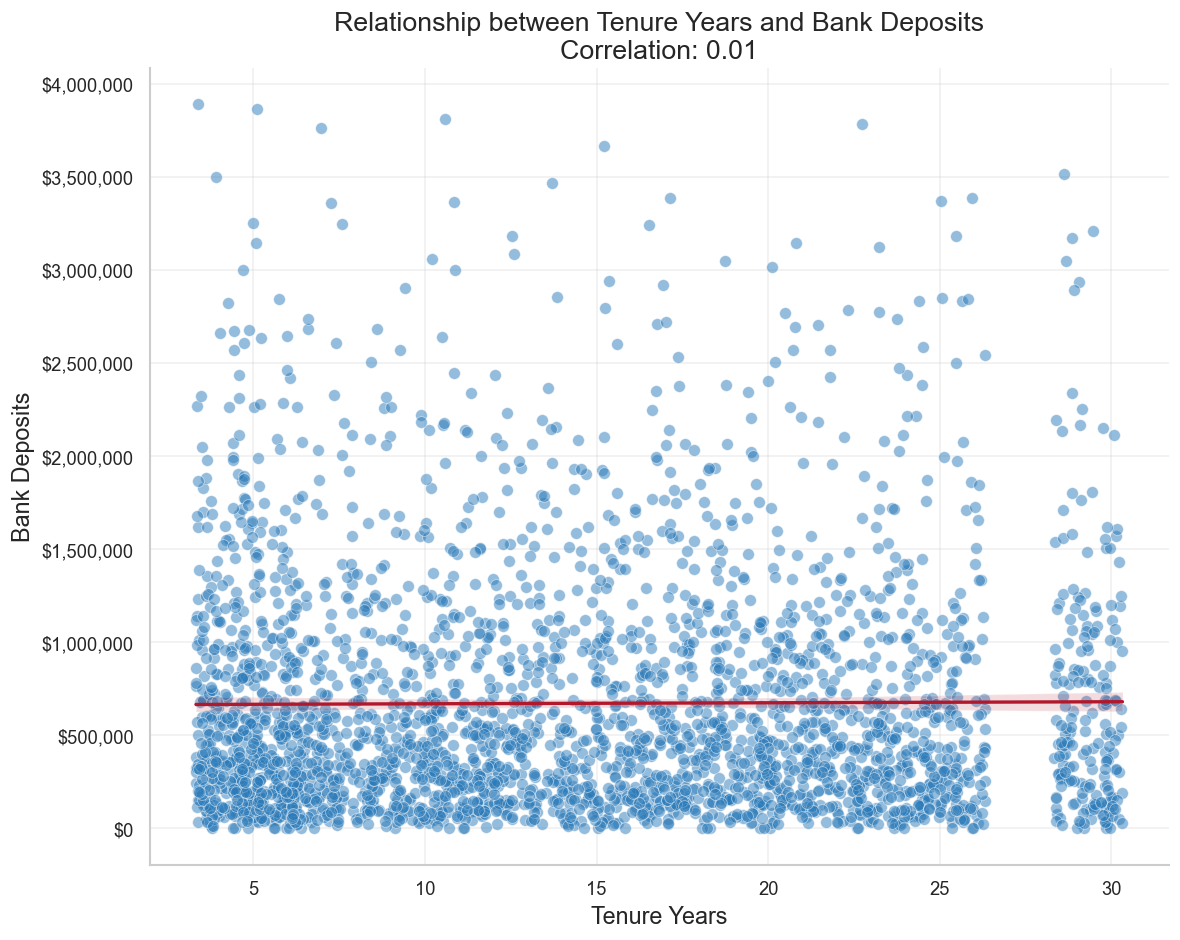

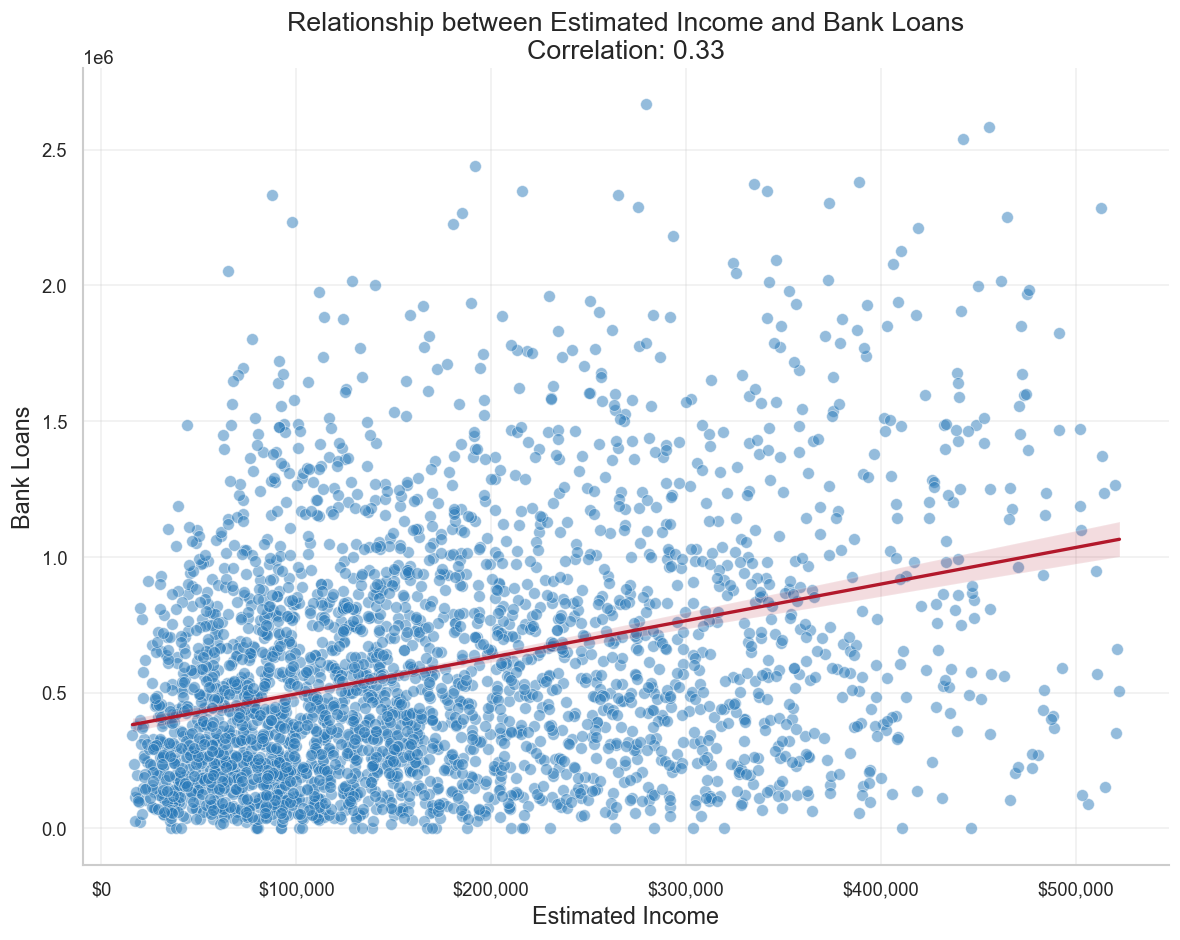

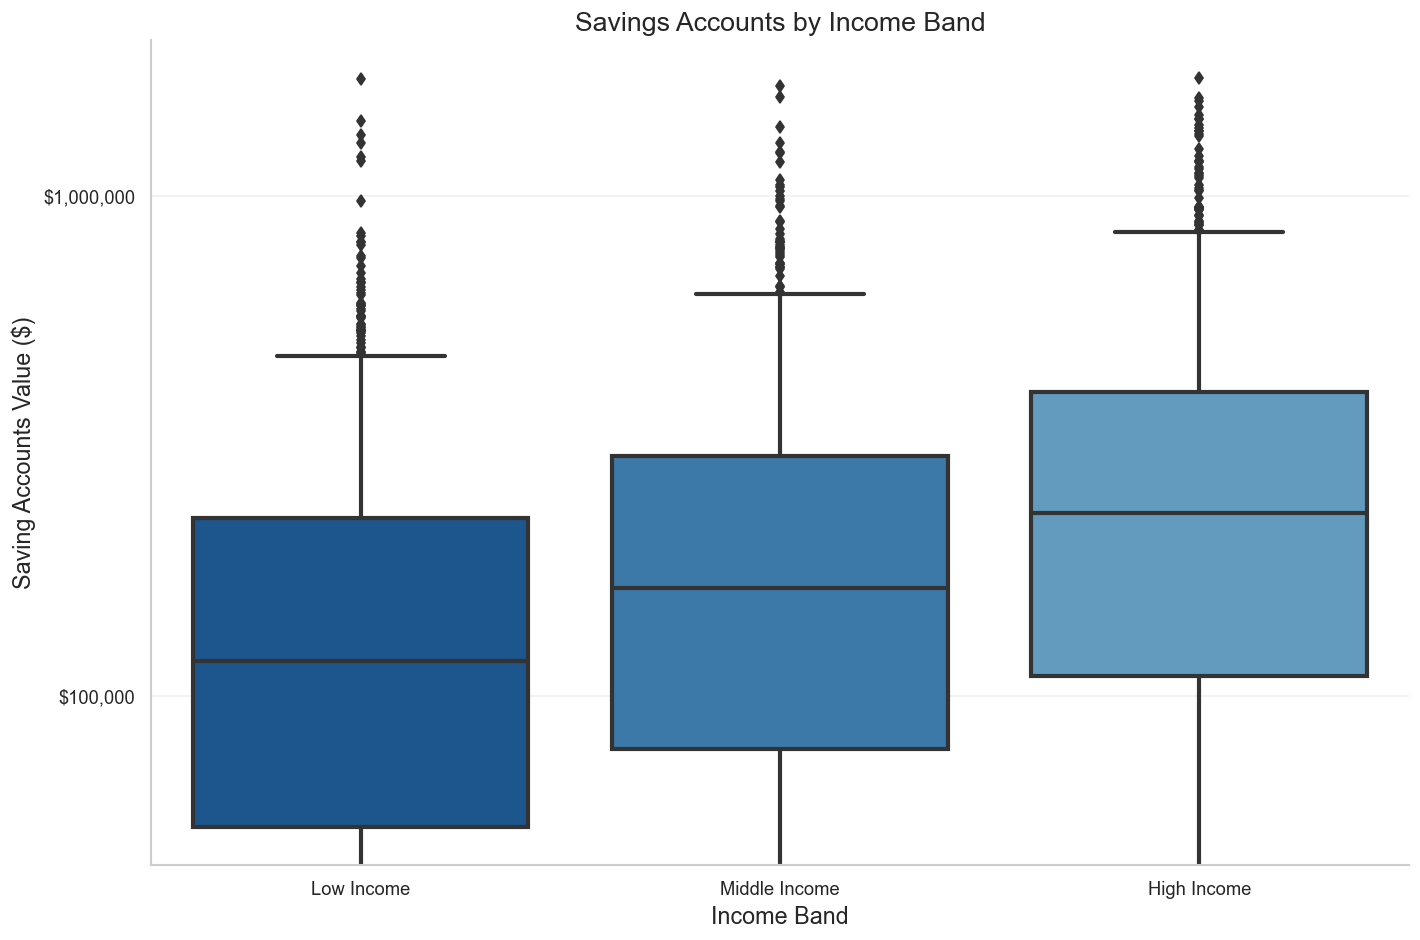

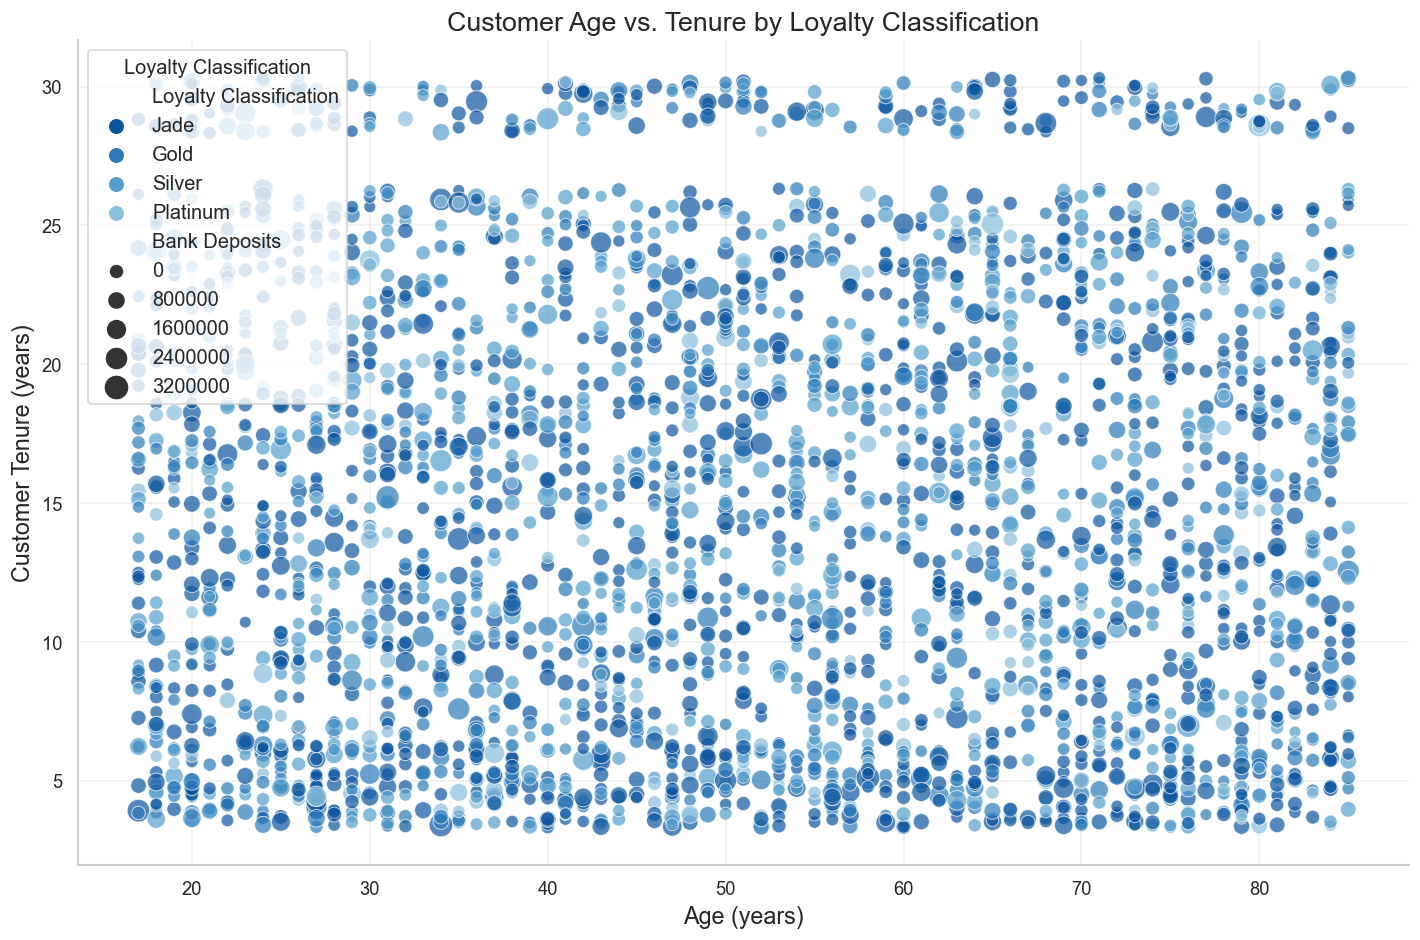

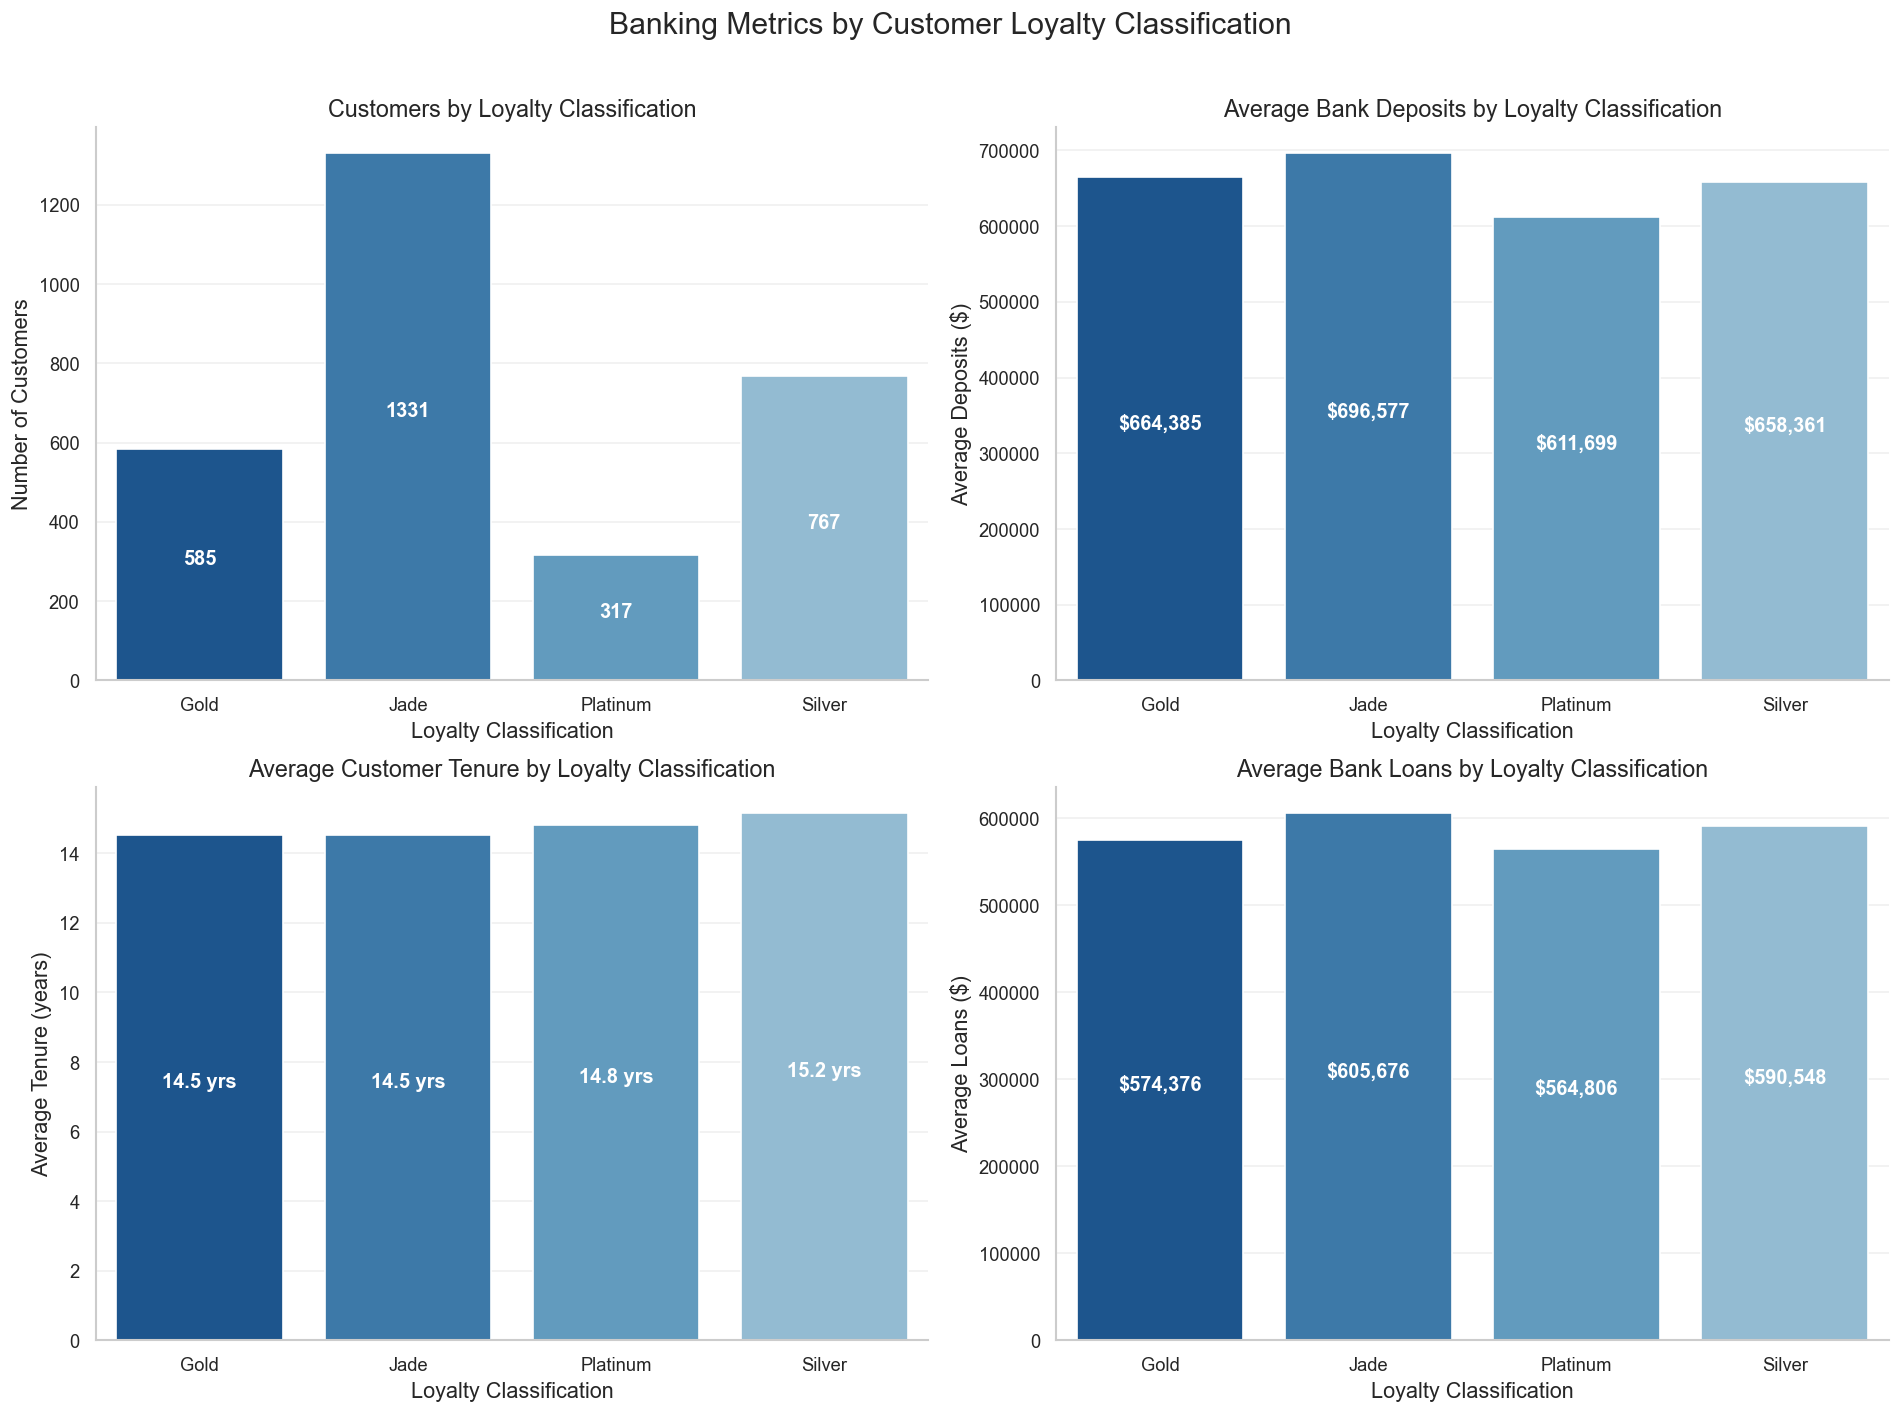

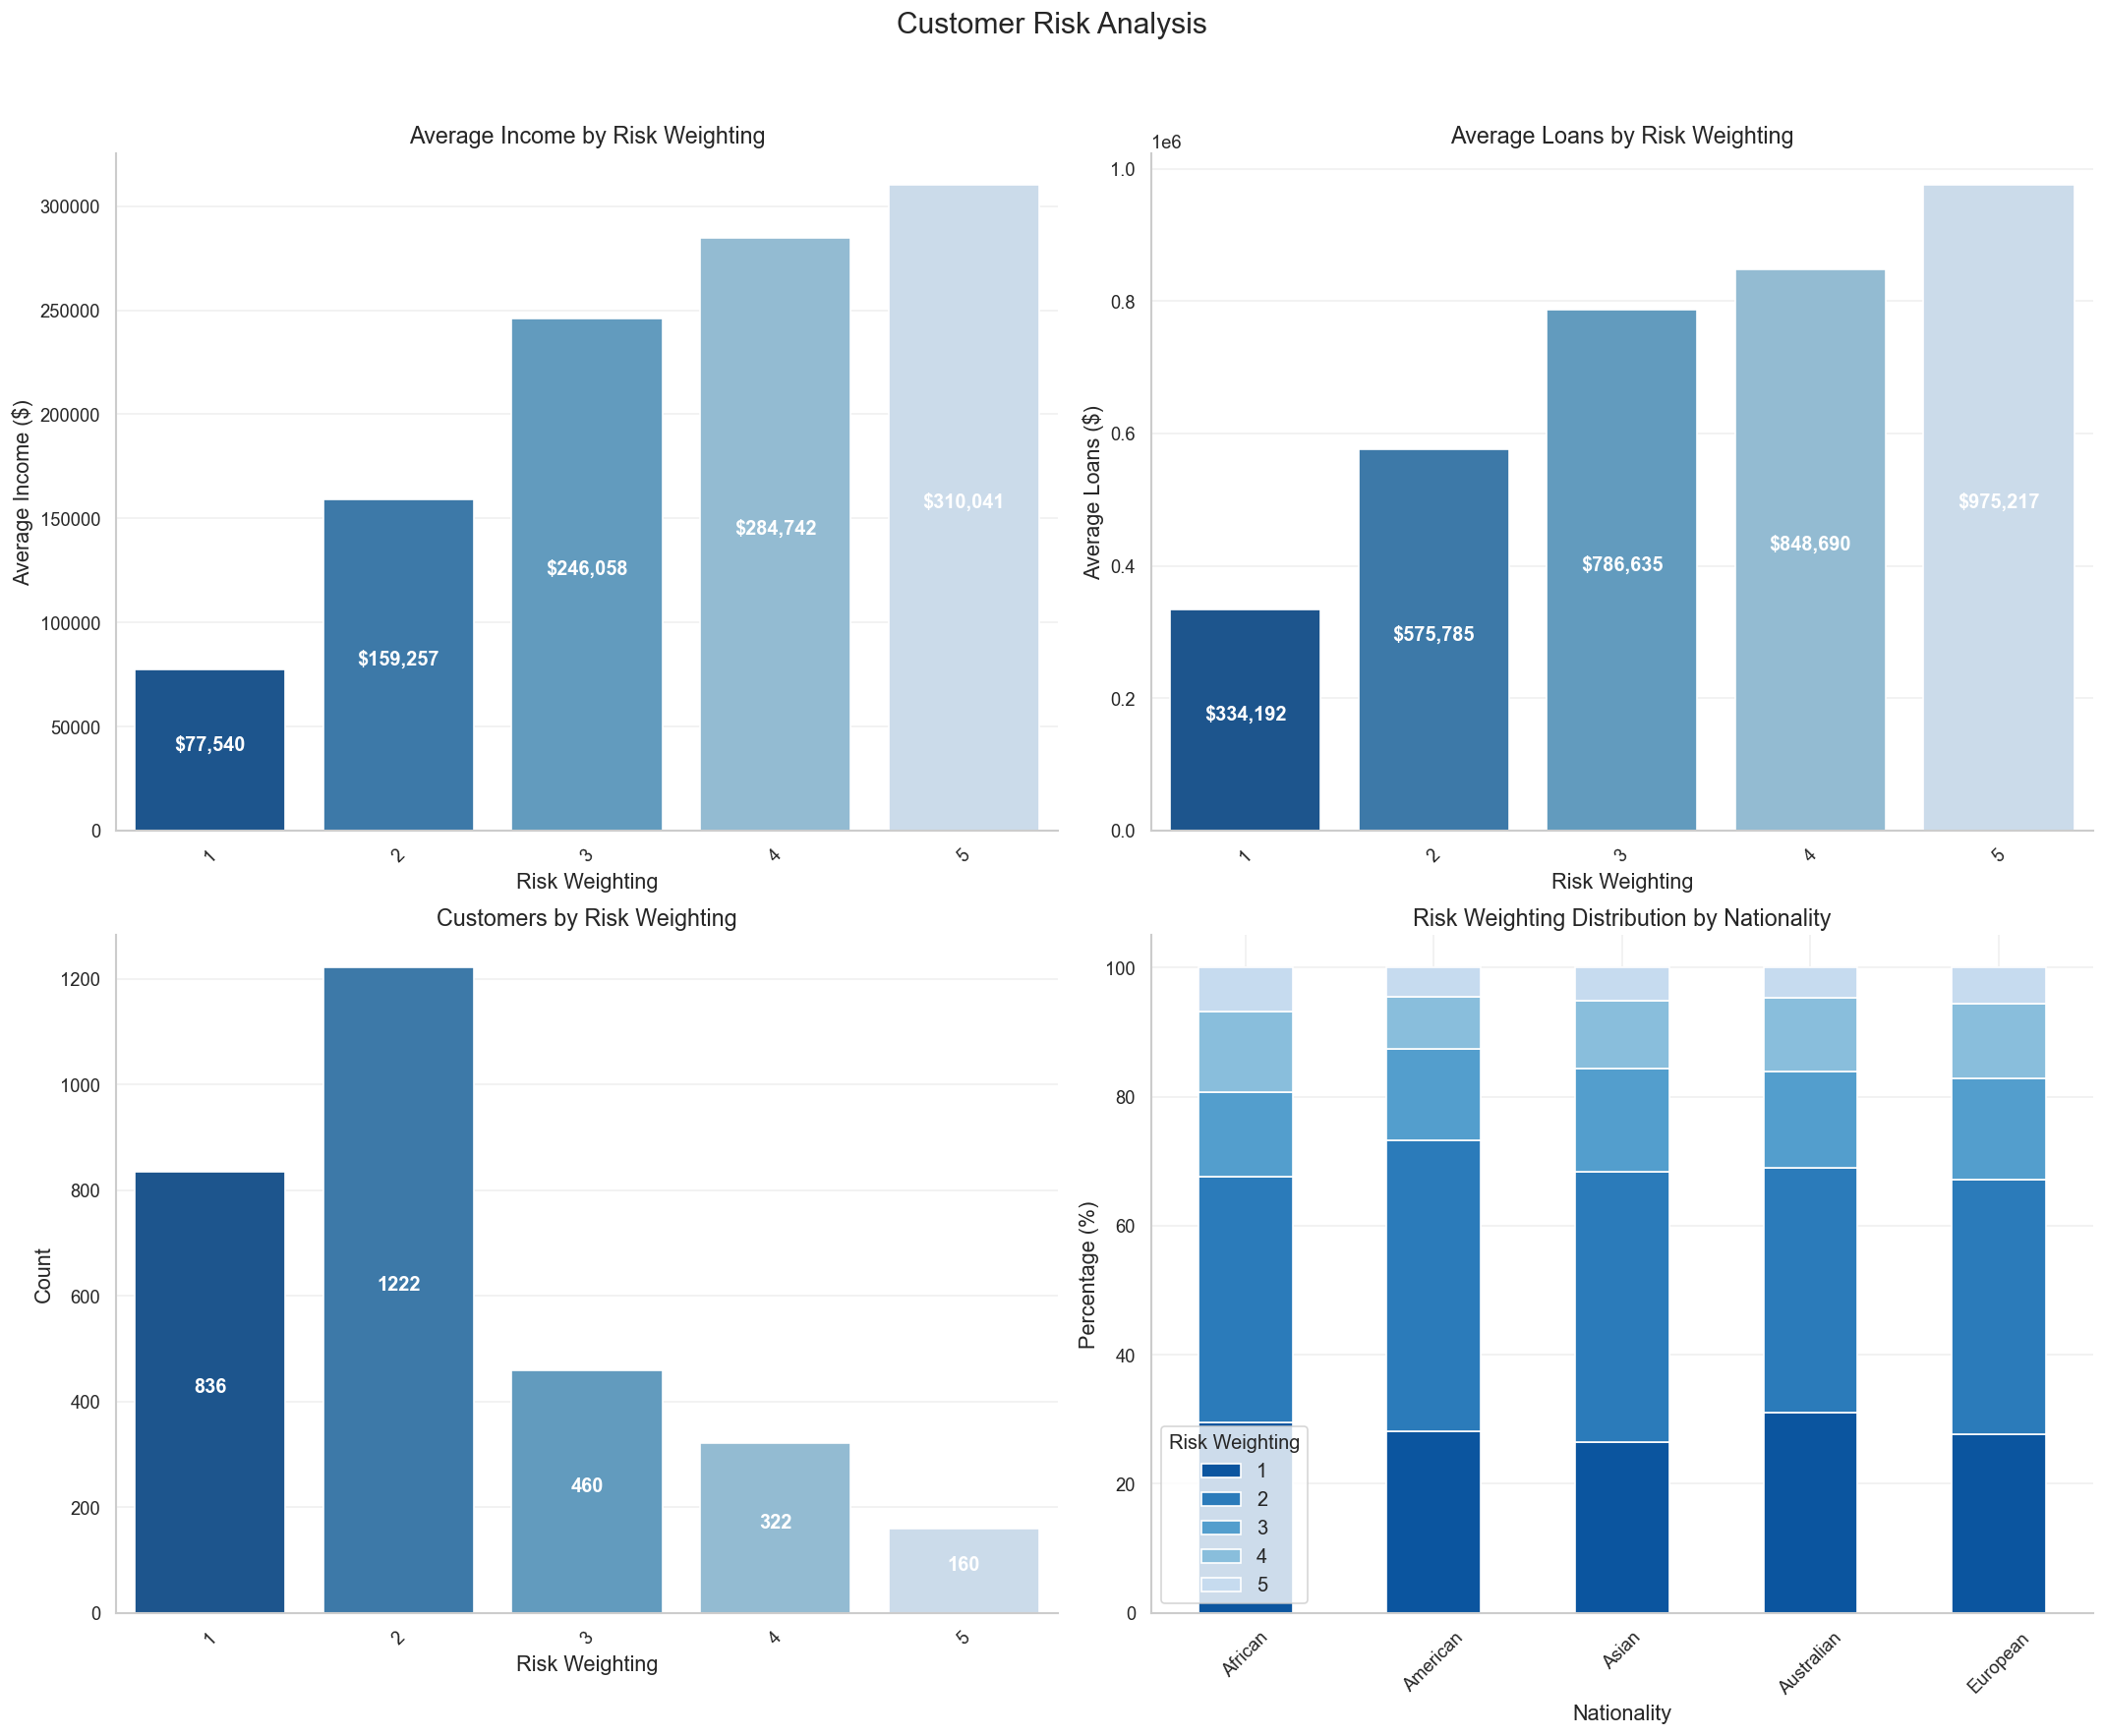

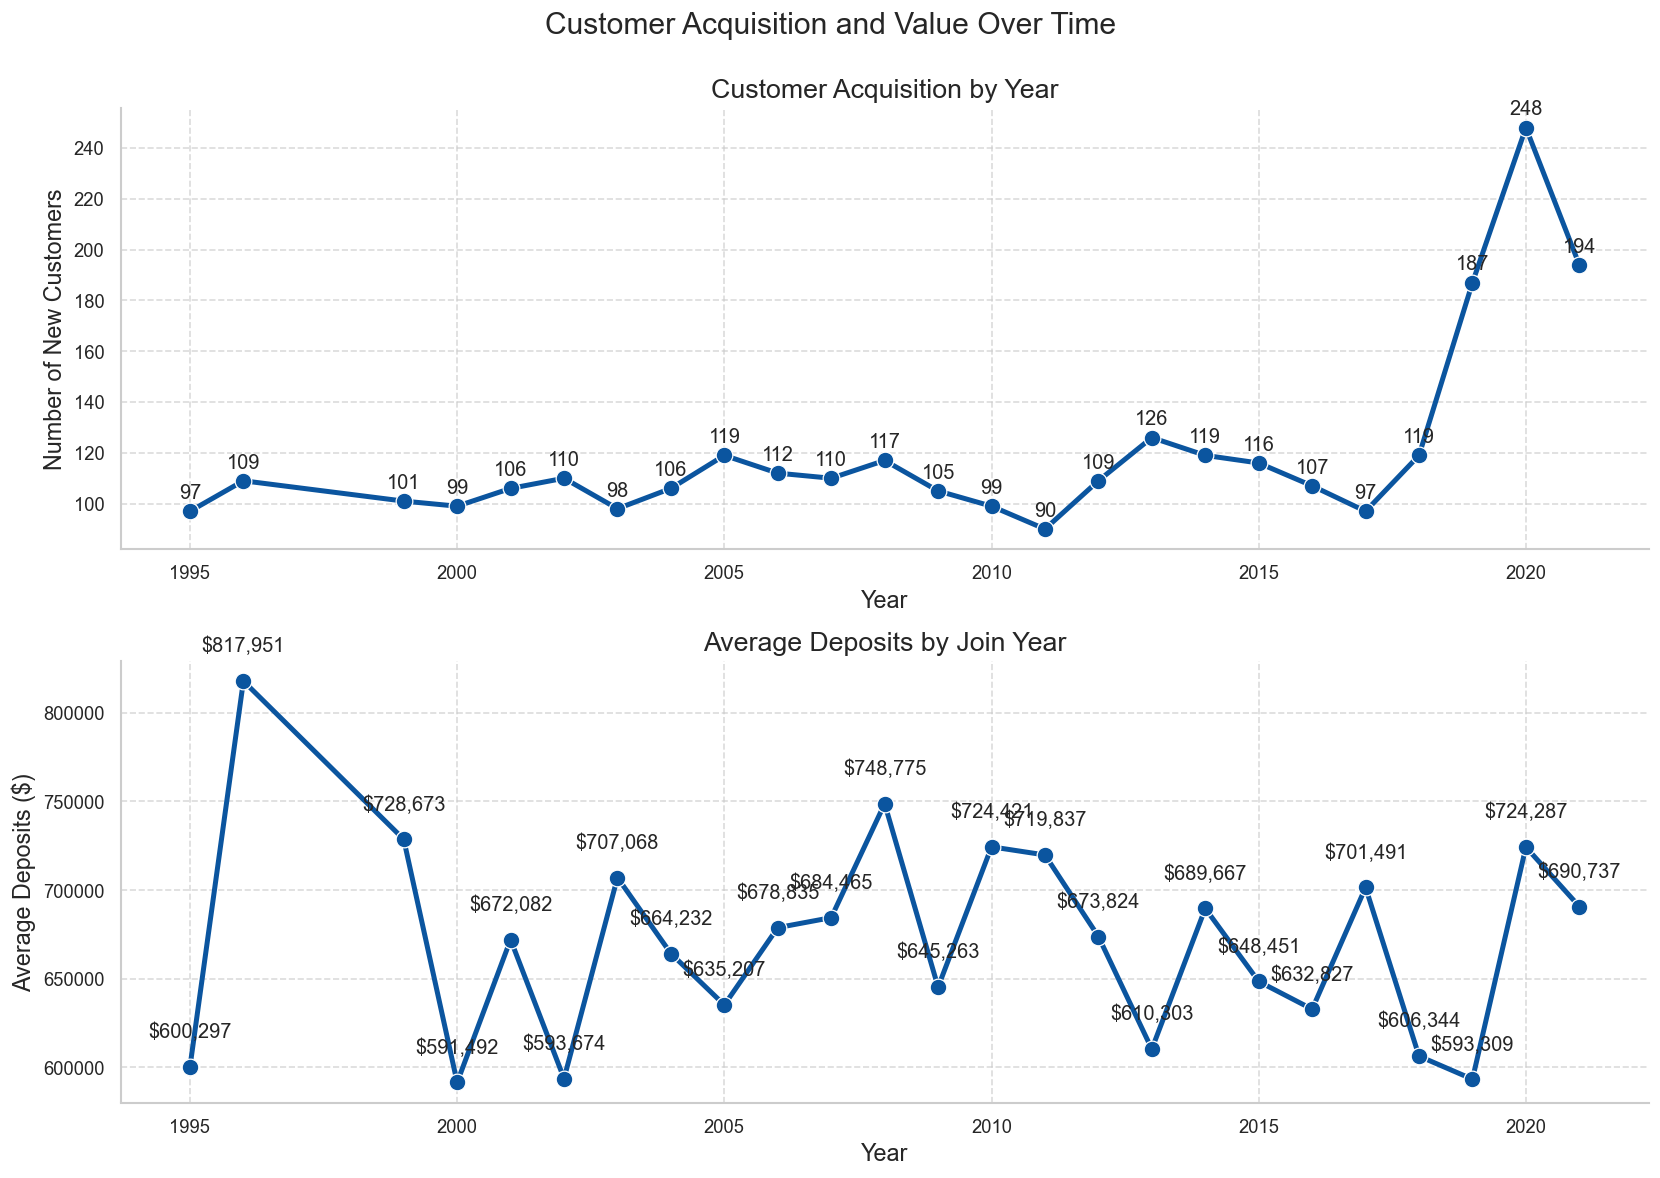

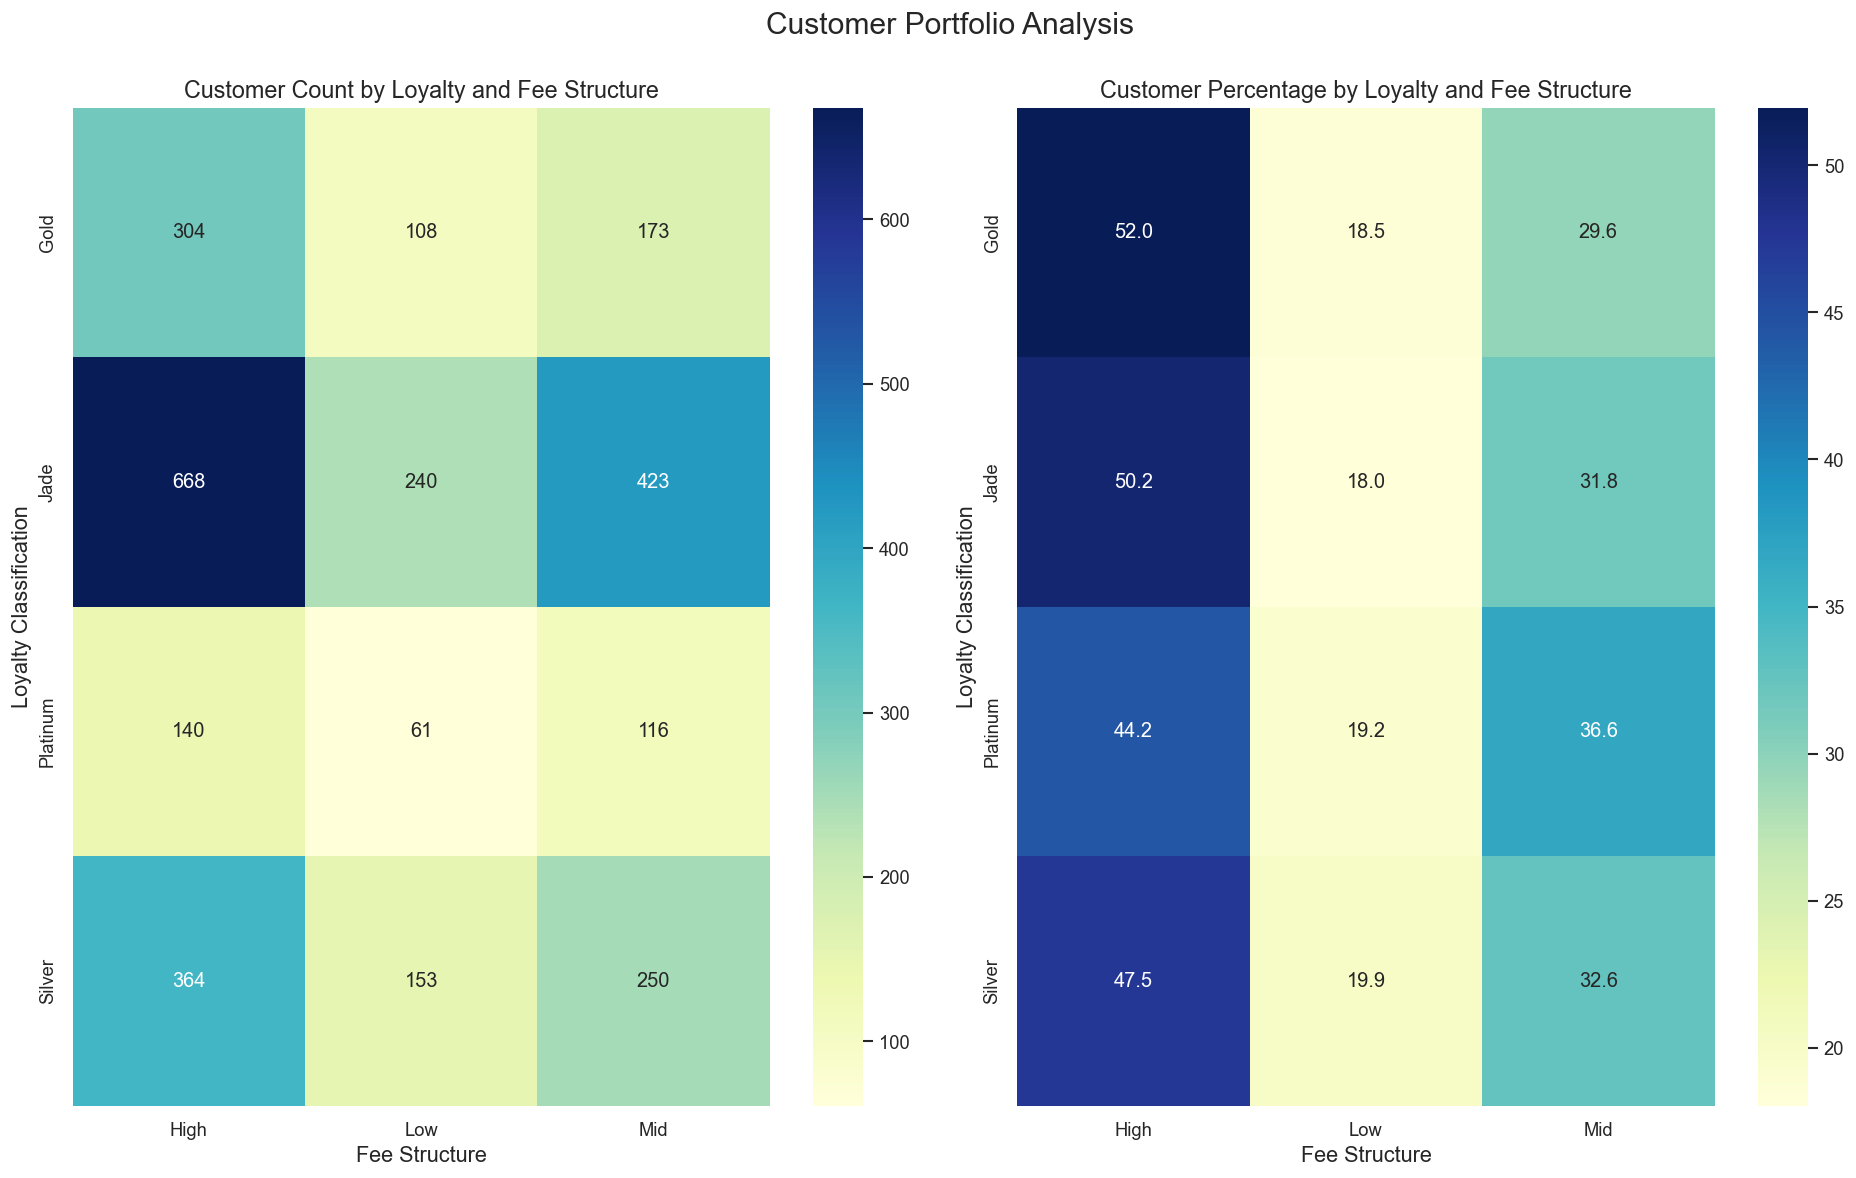

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from cycler import cycler
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Set a professional financial theme for all visualizations
def set_financial_theme():
    """Set a professional financial theme for all visualizations"""
    # Define a professional financial color palette
    financial_palette = ['#0b559f', '#2b7bba', '#539ecd', '#89bedc', '#c6dbef',
                         '#f4a582', '#d6604d', '#b2182b', '#67001f', '#014636']
    
    # Configure the style
    sns.set_theme(style="whitegrid", context="notebook")
    sns.set_palette(financial_palette)
    
    # Set better fonts
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif']
    
    # Increase font sizes for readability
    plt.rcParams['axes.labelsize'] = 13
    plt.rcParams['axes.titlesize'] = 16
    plt.rcParams['xtick.labelsize'] = 11
    plt.rcParams['ytick.labelsize'] = 11
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['figure.titlesize'] = 18
    
    # Higher DPI for better quality
    plt.rcParams['figure.dpi'] = 120
    plt.rcParams['savefig.dpi'] = 300
    
    # Better styling for plots
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.alpha'] = 0.3
    
    # Set default figure size
    plt.rcParams['figure.figsize'] = (10, 6)
    
    # Set default line properties
    plt.rcParams['lines.linewidth'] = 2.5
    plt.rcParams['lines.markersize'] = 8
    
    # Set the color cycle
    plt.rcParams['axes.prop_cycle'] = cycler('color', financial_palette)
    
    print("Professional financial theme applied to all visualizations")

# Apply the theme
set_financial_theme()

# Load and examine the data
df = pd.read_csv('Banking.csv')

# Display the first few rows with better formatting
print("Sample of Banking Dataset:")
print(df.head())

# Check the shape of the DataFrame
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")

# Get a concise summary of the DataFrame
print("\nDataFrame Information:")
df.info()

# Create income bands with better boundaries based on data distribution
print("\nEstimated Income Summary Statistics:")
print(df["Estimated Income"].describe())

# Define income band boundaries using quantile-based approach for more balanced groups
income_quantiles = [0, df["Estimated Income"].quantile(0.33), 
                   df["Estimated Income"].quantile(0.67), float('inf')]
labels = ['Low Income', 'Middle Income', 'High Income']

# Create the 'Income Band' column using pd.cut
df['Income Band'] = pd.cut(df['Estimated Income'], bins=income_quantiles, 
                          labels=labels, include_lowest=True)

# Function to create better visualizations for categorical variables
def plot_categorical_distribution(dataframe, columns, ncols=2, figsize=(16, 12)):
    """Create beautiful bar charts for categorical variables"""
    # Filter out 'Occupation' if it's in the columns list
    columns = [col for col in columns if col != "Occupation"]
    
    n = len(columns)
    nrows = (n + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = axes.flatten()
    
    for i, col in enumerate(columns):
        # Calculate value counts and percentages
        counts = dataframe[col].value_counts()
        counts_pct = (counts / counts.sum() * 100).round(1)
        
        # Sort for better visualization
        counts = counts.sort_values(ascending=False)
        
        # Create a DataFrame for easier plotting
        plot_df = pd.DataFrame({
            'Count': counts,
            'Percentage': counts_pct.loc[counts.index]
        })
        
        # Create the bar chart
        ax = axes[i]
        bars = sns.barplot(x=plot_df.index, y='Count', data=plot_df, ax=ax, 
                          palette='viridis')
        
        # Add count and percentage labels on top of bars
        for j, (count, pct) in enumerate(zip(plot_df['Count'], plot_df['Percentage'])):
            ax.text(j, count + (counts.max() * 0.01), f'{count:,}', 
                   ha='center', va='bottom', fontsize=10)
            ax.text(j, count/2, f'{pct}%', ha='center', va='center', 
                   fontsize=10, fontweight='bold', color='white')
        
        # Customize the chart
        ax.set_title(f'Distribution of {col}', fontsize=14, pad=10)
        ax.set_xlabel('')
        ax.set_ylabel('Count', fontsize=12)
        
        # Rotate x-labels if too many categories
        if len(counts) > 4:
            plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    # Hide empty subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Function to plot top occupations
def plot_top_occupations(dataframe, n=15, figsize=(12, 8)):
    """Plot only the top N occupations to avoid overcrowding"""
    # Get the top N occupations
    top_occupations = dataframe['Occupation'].value_counts().head(n)
    
    # Calculate percentages
    top_occupations_pct = (top_occupations / top_occupations.sum() * 100).round(1)
    
    # Create a horizontal bar chart
    plt.figure(figsize=figsize)
    ax = sns.barplot(y=top_occupations.index, x=top_occupations.values, 
                    palette='viridis', orient='h')
    
    # Add count and percentage labels
    for i, (count, pct) in enumerate(zip(top_occupations, top_occupations_pct)):
        ax.text(count + (top_occupations.max() * 0.01), i, f'{count:,} ({pct}%)', 
               va='center', fontsize=10)
    
    # Customize the chart
    ax.set_title(f'Top {n} Occupations', fontsize=16)
    ax.set_xlabel('Number of Customers', fontsize=14)
    ax.set_ylabel('', fontsize=14)
    
    plt.tight_layout()
    plt.show()

# Select categorical columns, excluding ID, name and occupation columns
categorical_cols = ["Risk Weighting", "Nationality", "Fee Structure",
                   "Loyalty Classification", "Properties Owned", "Income Band"]

# Plot the distribution of categorical variables
plot_categorical_distribution(df, categorical_cols)

# Plot top occupations separately
plot_top_occupations(df, n=15)

# Generate improved descriptive statistics for numerical columns
print("\nDescriptive Statistics for Numerical Columns:")
print(df.describe().T)

# Check for missing values with better visualization
missing_values = df.isnull().sum()
missing_pct = (missing_values / len(df) * 100).round(2)

# Only show if there are missing values
if missing_values.sum() > 0:
    missing_df = pd.DataFrame({
        'Missing Values': missing_values,
        'Percentage (%)': missing_pct
    })
    missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values('Missing Values', ascending=False)
    
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=missing_df.index, y='Percentage (%)', data=missing_df)
    plt.title('Missing Values by Column', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Missing Percentage (%)')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset.")

# Convert date column with better handling
df['Joined Bank'] = pd.to_datetime(df['Joined Bank'], format='%d-%m-%Y', errors='coerce')
print(f"Joined Bank column type: {df['Joined Bank'].dtype}")

# Check for any conversion errors
if df['Joined Bank'].isnull().any():
    print(f"Warning: {df['Joined Bank'].isnull().sum()} dates could not be converted properly.")

# Calculate customer tenure in years
current_date = pd.Timestamp.now()
df['Tenure Years'] = (current_date - df['Joined Bank']).dt.days / 365.25
print("\nCustomer Tenure Summary (Years):")
print(df['Tenure Years'].describe().round(2))

# Improved function for distribution plots - FIXED THE ERROR
def plot_distributions(dataframe, columns, bins=30, figsize=(18, 14)):
    """Create improved distribution plots for numerical variables"""
    n = len(columns)
    # Calculate optimal layout
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = axes.flatten()
    
    for i, col in enumerate(columns):
        ax = axes[i]
        
        # Create a distribution plot with both histogram and KDE - FIXED
        sns.histplot(
            data=dataframe,
            x=col,
            kde=True, 
            bins=bins, 
            ax=ax,
            color='#2b7bba', 
            edgecolor='white', 
            alpha=0.7
        )
        
        # Add KDE line with custom styling
        if dataframe[col].nunique() > 10:  # Only add KDE for continuous variables
            # We'll get the current axis limits
            xlim = ax.get_xlim()
            x_vals = np.linspace(xlim[0], xlim[1], 100)
            
            # Get KDE values manually
            kde = sns.kdeplot(
                data=dataframe[col], 
                ax=ax,
                color='#b2182b',
                linewidth=2
            )
        
        # Add statistical information
        stats_text = (f"Mean: {dataframe[col].mean():.2f}\n"
                     f"Median: {dataframe[col].median():.2f}\n"
                     f"Std Dev: {dataframe[col].std():.2f}")
        
        # Place text in the upper right
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
               verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Add a title and labels
        ax.set_title(f'Distribution of {col}', fontsize=14)
        ax.set_xlabel(col, fontsize=12)
        ax.set_ylabel('Frequency', fontsize=12)
        
        # Format the x-axis for currency values if needed
        if any(term in col.lower() for term in ['income', 'balance', 'savings', 'deposits', 'accounts', 'lending']):
            from matplotlib.ticker import FuncFormatter
            ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
    
    # Hide empty subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Select numerical columns for distribution analysis
numerical_cols = ['Age', 'Estimated Income', 'Superannuation Savings', 'Credit Card Balance', 
                  'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts', 
                  'Foreign Currency Account', 'Business Lending', 'Tenure Years']

# Plot distributions
plot_distributions(df, numerical_cols)

# Improved correlation heatmap
def plot_correlation_matrix(dataframe, columns):
    """Create an improved correlation heatmap"""
    correlation_matrix = dataframe[columns].corr()
    
    # Set up the matplotlib figure
    plt.figure(figsize=(14, 12))
    
    # Create a custom diverging colormap
    cmap = sns.diverging_palette(240, 10, as_cmap=True)
    
    # Draw the heatmap with better formatting
    mask = np.triu(correlation_matrix)
    heatmap = sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap=cmap, 
                vmin=-1, vmax=1, center=0, square=True, linewidths=.5, 
                cbar_kws={"shrink": .8}, fmt=".2f")
    
    # Improve the visualization
    heatmap.set_title('Correlation Matrix of Numerical Features', fontdict={'fontsize':18}, pad=16)
    
    # Rotate the tick labels and set alignment
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

# Plot the correlation matrix
plot_correlation_matrix(df, numerical_cols)

# Improved scatter plots with regression lines - Fixed potential errors
def plot_relationships(dataframe, pairs_list, hue_column=None):
    """Create improved scatter plots with regression lines"""
    for x_col, y_col in pairs_list:
        if hue_column:
            g = sns.lmplot(
                data=dataframe,
                x=x_col,
                y=y_col,
                hue=hue_column,
                height=8,
                aspect=1.2,
                scatter_kws={'alpha': 0.5, 's': 50, 'edgecolor': 'w', 'linewidth': 0.5},
                line_kws={'linewidth': 2}
            )
            # Title needs to be set differently for lmplot
            g.fig.suptitle(f'Relationship between {x_col} and {y_col}\nby {hue_column}', fontsize=16)
            g.fig.subplots_adjust(top=0.9)  # Adjust to prevent title overlap
        else:
            plt.figure(figsize=(10, 8))
            ax = sns.regplot(
                data=dataframe,
                x=x_col,
                y=y_col,
                scatter_kws={'alpha': 0.5, 's': 50, 'color': '#2b7bba', 'edgecolor': 'w', 'linewidth': 0.5},
                line_kws={'color': '#b2182b', 'linewidth': 2}
            )
            
            # Calculate correlation coefficient
            corr = dataframe[x_col].corr(dataframe[y_col])
            plt.title(f'Relationship between {x_col} and {y_col}\nCorrelation: {corr:.2f}', fontsize=16)
            
            # Format axes for financial values
            if any(term in x_col.lower() for term in ['income', 'balance', 'savings', 'deposits', 'accounts', 'lending']):
                from matplotlib.ticker import FuncFormatter
                plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
            
            if any(term in y_col.lower() for term in ['income', 'balance', 'savings', 'deposits', 'accounts', 'lending']):
                from matplotlib.ticker import FuncFormatter
                plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'${y:,.0f}'))
            
            plt.xlabel(x_col, fontsize=14)
            plt.ylabel(y_col, fontsize=14)
            plt.tight_layout()
            plt.show()

# Pairs of variables to analyze
pairs_to_plot = [
    ('Bank Deposits', 'Saving Accounts'),
    ('Checking Accounts', 'Saving Accounts'),
    ('Checking Accounts', 'Foreign Currency Account'),
    ('Age', 'Superannuation Savings'),
    ('Estimated Income', 'Checking Accounts'),
    ('Bank Loans', 'Credit Card Balance'),
    ('Business Lending', 'Bank Loans'),
    ('Tenure Years', 'Bank Deposits'),
    ('Estimated Income', 'Bank Loans')
]

# Plot relationships
plot_relationships(df, pairs_to_plot)

# Create additional plots by segmentation

# Plot savings by income band
plt.figure(figsize=(12, 8))
sns.boxplot(x='Income Band', y='Saving Accounts', data=df)
plt.title('Savings Accounts by Income Band', fontsize=16)
plt.xlabel('Income Band', fontsize=14)
plt.ylabel('Saving Accounts Value ($)', fontsize=14)
plt.yscale('log')  # Use log scale for better visualization of wide ranges
# Format y-axis with dollar signs
from matplotlib.ticker import FuncFormatter
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'${y:,.0f}'))
plt.tight_layout()
plt.show()

# Plot relationship between age and tenure
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=df,
    x='Age',
    y='Tenure Years',
    hue='Loyalty Classification',
    size='Bank Deposits',
    sizes=(50, 200),
    alpha=0.7
)
plt.title('Customer Age vs. Tenure by Loyalty Classification', fontsize=16)
plt.xlabel('Age (years)', fontsize=14)
plt.ylabel('Customer Tenure (years)', fontsize=14)
plt.legend(title='Loyalty Classification', title_fontsize=12)
plt.tight_layout()
plt.show()

# Create a dashboard-style visualization of key metrics by loyalty class
plt.figure(figsize=(16, 12))

# Customer count by loyalty
plt.subplot(2, 2, 1)
loyalty_counts = df['Loyalty Classification'].value_counts().sort_index()
ax1 = sns.barplot(x=loyalty_counts.index, y=loyalty_counts.values)
for i, count in enumerate(loyalty_counts):
    ax1.text(i, count/2, f'{count}', ha='center', color='white', fontweight='bold')
plt.title('Customers by Loyalty Classification', fontsize=14)
plt.xlabel('Loyalty Classification')
plt.ylabel('Number of Customers')

# Average deposits by loyalty
plt.subplot(2, 2, 2)
avg_deposits = df.groupby('Loyalty Classification')['Bank Deposits'].mean().sort_index()
ax2 = sns.barplot(x=avg_deposits.index, y=avg_deposits.values)
for i, val in enumerate(avg_deposits):
    ax2.text(i, val/2, f'${val:,.0f}', ha='center', color='white', fontweight='bold')
plt.title('Average Bank Deposits by Loyalty Classification', fontsize=14)
plt.xlabel('Loyalty Classification')
plt.ylabel('Average Deposits ($)')

# Average tenure by loyalty
plt.subplot(2, 2, 3)
avg_tenure = df.groupby('Loyalty Classification')['Tenure Years'].mean().sort_index()
ax3 = sns.barplot(x=avg_tenure.index, y=avg_tenure.values)
for i, val in enumerate(avg_tenure):
    ax3.text(i, val/2, f'{val:.1f} yrs', ha='center', color='white', fontweight='bold')
plt.title('Average Customer Tenure by Loyalty Classification', fontsize=14)
plt.xlabel('Loyalty Classification')
plt.ylabel('Average Tenure (years)')

# Average loans by loyalty
plt.subplot(2, 2, 4)
avg_loans = df.groupby('Loyalty Classification')['Bank Loans'].mean().sort_index()
ax4 = sns.barplot(x=avg_loans.index, y=avg_loans.values)
for i, val in enumerate(avg_loans):
    ax4.text(i, val/2, f'${val:,.0f}', ha='center', color='white', fontweight='bold')
plt.title('Average Bank Loans by Loyalty Classification', fontsize=14)
plt.xlabel('Loyalty Classification')
plt.ylabel('Average Loans ($)')

plt.suptitle('Banking Metrics by Customer Loyalty Classification', fontsize=18, y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# Add a segmentation analysis by Risk Weighting
# Create a figure with multiple subplots
plt.figure(figsize=(18, 15))

# Average Income by Risk Weighting
plt.subplot(2, 2, 1)
avg_income = df.groupby('Risk Weighting')['Estimated Income'].mean().sort_values()
ax1 = sns.barplot(x=avg_income.index, y=avg_income.values)
for i, val in enumerate(avg_income):
    ax1.text(i, val/2, f'${val:,.0f}', ha='center', color='white', fontweight='bold')
plt.title('Average Income by Risk Weighting', fontsize=14)
plt.xlabel('Risk Weighting')
plt.ylabel('Average Income ($)')
plt.xticks(rotation=45)

# Average Loans by Risk Weighting
plt.subplot(2, 2, 2)
avg_loans = df.groupby('Risk Weighting')['Bank Loans'].mean().sort_values()
ax2 = sns.barplot(x=avg_loans.index, y=avg_loans.values)
for i, val in enumerate(avg_loans):
    ax2.text(i, val/2, f'${val:,.0f}', ha='center', color='white', fontweight='bold')
plt.title('Average Loans by Risk Weighting', fontsize=14)
plt.xlabel('Risk Weighting')
plt.ylabel('Average Loans ($)')
plt.xticks(rotation=45)

# Count of customers by Risk Weighting
plt.subplot(2, 2, 3)
risk_counts = df['Risk Weighting'].value_counts().sort_index()
ax3 = sns.barplot(x=risk_counts.index, y=risk_counts.values)
for i, count in enumerate(risk_counts):
    ax3.text(i, count/2, f'{count}', ha='center', color='white', fontweight='bold')
plt.title('Customers by Risk Weighting', fontsize=14)
plt.xlabel('Risk Weighting')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Risk Weighting by Nationality
plt.subplot(2, 2, 4)
risk_by_nationality = pd.crosstab(df['Nationality'], df['Risk Weighting'], normalize='index') * 100
risk_by_nationality.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Risk Weighting Distribution by Nationality', fontsize=14)
plt.xlabel('Nationality')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend(title='Risk Weighting')

plt.suptitle('Customer Risk Analysis', fontsize=18, y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# Add a time-based analysis using the customer's join date
# First, create a year column for easier analysis
df['Join Year'] = df['Joined Bank'].dt.year

# Create a time trend analysis
plt.figure(figsize=(14, 10))

# Customer acquisition over time
plt.subplot(2, 1, 1)
year_counts = df['Join Year'].value_counts().sort_index()
ax1 = sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', linewidth=3, markersize=10)
for i, count in enumerate(year_counts):
    ax1.text(year_counts.index[i], count + (year_counts.max() * 0.02), f'{count}', ha='center')
plt.title('Customer Acquisition by Year', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of New Customers', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

# Average deposits by join year
plt.subplot(2, 1, 2)
avg_deposits_by_year = df.groupby('Join Year')['Bank Deposits'].mean()
ax2 = sns.lineplot(x=avg_deposits_by_year.index, y=avg_deposits_by_year.values, marker='o', linewidth=3, markersize=10)
for i, val in enumerate(avg_deposits_by_year):
    ax2.text(avg_deposits_by_year.index[i], val + (avg_deposits_by_year.max() * 0.02), f'${val:,.0f}', ha='center')
plt.title('Average Deposits by Join Year', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average Deposits ($)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Customer Acquisition and Value Over Time', fontsize=18, y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# Add a portfolio analysis by Fee Structure and Loyalty Classification
plt.figure(figsize=(16, 10))

# Cross-tabulation of Fee Structure and Loyalty Classification
loyalty_fee_crosstab = pd.crosstab(df['Loyalty Classification'], df['Fee Structure'])
loyalty_fee_pct = pd.crosstab(df['Loyalty Classification'], df['Fee Structure'], normalize='index') * 100

# Create a heatmap of the counts
plt.subplot(1, 2, 1)
sns.heatmap(loyalty_fee_crosstab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Customer Count by Loyalty and Fee Structure', fontsize=14)
plt.xlabel('Fee Structure')
plt.ylabel('Loyalty Classification')

# Create a heatmap of the percentages
plt.subplot(1, 2, 2)
sns.heatmap(loyalty_fee_pct, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Customer Percentage by Loyalty and Fee Structure', fontsize=14)
plt.xlabel('Fee Structure')
plt.ylabel('Loyalty Classification')

plt.suptitle('Customer Portfolio Analysis', fontsize=18, y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()